# Stage 1 data

##Pre-processing

**Stage 1: Pre-processing instructions**
- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with > 50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.

In [ ]:
# File URL
#file_url = "https://drive.google.com/uc?id=1pA8DDYmQuaLyxADCOZe1QaSQwF16q1J6"

In [ ]:
# Start coding from here with Stage 1 dataset
# import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from datetime import datetime
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Input
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
from sklearn.datasets import make_classification
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



# import the data with the url provided
data = pd.read_csv('https://drive.google.com/uc?id=1pA8DDYmQuaLyxADCOZe1QaSQwF16q1J6')

# keeping results the same, use seed
seed = 42
np.random.seed(seed)



In [ ]:
# View the data shape
print(data.shape)

# Display the first few rows
data.head()

(25059, 16)


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen


Shows there are 16 different columnns and 25059 rows.

Initial view of the data
- Shows LearnerCode is the studientidentifier, which we dont need for predictions.
- There seems to be a number of 'NaN' values on columns DiscountType and HomeState at least.
- CompletedCourse can be seen to be the Y value that we need - however this is as completed course, as opposed to drop out of the student.


In [ ]:
#dropping LearnerCode column
data.drop(['LearnerCode'], axis=1, inplace=True)

data.head()

,CentreName,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen


In [ ]:
# Show metadata of data.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CentreName             25059 non-null  object
 1   BookingType            25059 non-null  object
 2   LeadSource             25059 non-null  object
 3   DiscountType           7595 non-null   object
 4   DateofBirth            25059 non-null  object
 5   Gender                 25059 non-null  object
 6   Nationality            25059 non-null  object
 7   HomeState              8925 non-null   object
 8   HomeCity               21611 non-null  object
 9   CourseLevel            25059 non-null  object
 10  CourseName             25059 non-null  object
 11  IsFirstIntake          25059 non-null  bool  
 12  CompletedCourse        25059 non-null  object
 13  ProgressionDegree      24184 non-null  object
 14  ProgressionUniversity  25059 non-null  object
dtypes: bool(1), object(

Shows mostly object type, with one boolean and integer.

In [ ]:
print(f'\n count of unique values in column \n')

# check for cardinality - counts number of unique values (excludes NaN values)
print(data.apply(lambda col: col.nunique()))

print(f'\n unique values in column \n')

# look at the values
print(data.apply(lambda col: col.unique()))



 count of unique values in column 

CentreName                 19
BookingType                 2
LeadSource                  7
DiscountType               11
DateofBirth              4705
Gender                      2
Nationality               151
HomeState                2448
HomeCity                 5881
CourseLevel                 4
CourseName                172
IsFirstIntake               2
CompletedCourse             2
ProgressionDegree        2616
ProgressionUniversity      40
dtype: int64

 unique values in column 

CentreName               [ISC_Aberdeen, ISC_Cardiff, ISC_Dublin, ISC_Du...
BookingType                                                [Agent, Direct]
LeadSource               [Standard Agent Booking, Sponsor, APD, Digital...
DiscountType             [nan, Other Scholarships / Bursaries, Bursary,...
DateofBirth              [13/01/1998, 12/2/1998, 7/4/2000, 18/05/1999, ...
Gender                                                      [Male, Female]
Nationality           

Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).

-- There are 4 columns with that have more than 200 unique values are:

- DateofBirth (4705 unique values)
- HomeState (2448 unique values)
- HomeCity (5881 unique values)
- ProgressionDegree (2616 unique values)

However, DateofBirth is not categorical, so we can keep this in as we can calculate age from this which is a numeric field. The other 3 columns can be removed

In [ ]:
#dropping categorical columns that have more than 200 unique values i.e. HomeState, HomeCity, ProgressionDegree
data.drop(['HomeState', 'HomeCity', 'ProgressionDegree'], axis=1, inplace=True)


In [ ]:
# ensure 12 columns left in the data after the removals
print(f'\n shape of data: ', data.shape)
data.head()



 shape of data:  (25059, 12)


,CentreName,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionUniversity
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,University of Aberdeen
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,University of Aberdeen
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,University of Aberdeen
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,International Year Two,Business Management and Finance International ...,True,Yes,University of Aberdeen
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,University of Aberdeen


In [ ]:
# Find missing values.
data.isnull().sum()

,0
CentreName,0
BookingType,0
LeadSource,0
DiscountType,17464
DateofBirth,0
Gender,0
Nationality,0
CourseLevel,0
CourseName,0
IsFirstIntake,0


The feature DiscountType has 17464 data as null.
There is a total of 25059 rows. Which means about 70% of data in this column is missing.

In [ ]:
# Removing DiscountType column as it has > 50% data missing

data.drop(['DiscountType'], axis=1, inplace=True)


In [ ]:
# ensure 11 columns left in the data after the removals
print(f'\n shape of data: ', data.shape)
data.head()


 shape of data:  (25059, 11)


,CentreName,BookingType,LeadSource,DateofBirth,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionUniversity
0,ISC_Aberdeen,Agent,Standard Agent Booking,13/01/1998,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,University of Aberdeen
1,ISC_Aberdeen,Agent,Standard Agent Booking,12/2/1998,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,University of Aberdeen
2,ISC_Aberdeen,Agent,Standard Agent Booking,7/4/2000,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,University of Aberdeen
3,ISC_Aberdeen,Agent,Standard Agent Booking,18/05/1999,Male,Chinese,International Year Two,Business Management and Finance International ...,True,Yes,University of Aberdeen
4,ISC_Aberdeen,Agent,Standard Agent Booking,19/04/1996,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,University of Aberdeen


In [ ]:
# check for cardinality - counts number of unique values (excludes NaN values)
print(data.apply(lambda col: col.nunique()))

print(f'\n unique values in column \n')

# look at the values
print(data.apply(lambda col: col.unique()))


CentreName                 19
BookingType                 2
LeadSource                  7
DateofBirth              4705
Gender                      2
Nationality               151
CourseLevel                 4
CourseName                172
IsFirstIntake               2
CompletedCourse             2
ProgressionUniversity      40
dtype: int64

 unique values in column 

CentreName               [ISC_Aberdeen, ISC_Cardiff, ISC_Dublin, ISC_Du...
BookingType                                                [Agent, Direct]
LeadSource               [Standard Agent Booking, Sponsor, APD, Digital...
DateofBirth              [13/01/1998, 12/2/1998, 7/4/2000, 18/05/1999, ...
Gender                                                      [Male, Female]
Nationality              [Chinese, Iraqi, Kenyan, British, Kazakhstani,...
CourseLevel              [Pre-Masters, Foundation, International Year T...
CourseName               [Business and Law Pre-Masters, Life Sciences U...
IsFirstIntake                

Looking for ordinal data:
- CourseLevel seems to be a potential ordinal data. The rest dont seem to be ordinal

In [ ]:
# see what the values in CourseLevel are

data['CourseLevel'].unique()

#It looks like the order could be: foundation, int year 1, int year 2, pre masters
order = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters']

# create ordinal encoder
ordinal_encoder = OrdinalEncoder(categories=[order])

#reshape data
data['CourseLevel'] = ordinal_encoder.fit_transform(data[['CourseLevel']]).astype(int)

data.head()

,CentreName,BookingType,LeadSource,DateofBirth,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionUniversity
0,ISC_Aberdeen,Agent,Standard Agent Booking,13/01/1998,Male,Chinese,3,Business and Law Pre-Masters,True,Yes,University of Aberdeen
1,ISC_Aberdeen,Agent,Standard Agent Booking,12/2/1998,Male,Chinese,0,Life Sciences Undergraduate Foundation Programme,False,Yes,University of Aberdeen
2,ISC_Aberdeen,Agent,Standard Agent Booking,7/4/2000,Male,Chinese,2,Business Management and Finance International ...,False,Yes,University of Aberdeen
3,ISC_Aberdeen,Agent,Standard Agent Booking,18/05/1999,Male,Chinese,2,Business Management and Finance International ...,True,Yes,University of Aberdeen
4,ISC_Aberdeen,Agent,Standard Agent Booking,19/04/1996,Male,Chinese,3,Business and Law Pre-Masters,True,Yes,University of Aberdeen


Can see the CourseLevel has been converted to numbers, with the ordinal encoder wih the order that was given.

Next we do one-hot encoding. Except for courselevel (as already ordered as per above), date of birth (will calculate age in next steps), isfirstintake (no value to do one hot encoding for this) and similarly for completed course. Will convert the last two to numbers later on.

In [ ]:
# perform one-hot encoding for categorical data
# except courselevel, date of birth, IsFirstIntake and completed course (y)
# the rest dont seem to have an order

data_df = pd.get_dummies(data,
                         columns=["CentreName", "BookingType", "LeadSource", "Gender", "Nationality", "CourseName", "IsFirstIntake", "ProgressionUniversity", "CompletedCourse"],
                         drop_first=True,
                         dtype=int)

data_df.head()


,DateofBirth,CourseLevel,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,CentreName_ISC_Lancaster,...,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,CompletedCourse_Yes
0,13/01/1998,3,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,12/2/1998,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,7/4/2000,2,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,18/05/1999,2,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,19/04/1996,3,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
data_df.shape

(25059, 390)

One hot encoding increasing number of columns onto 390.

## Feature engineering

In [ ]:

# Convert the DOB to datetime
data_df['DOB'] = pd.to_datetime(data_df['DateofBirth'],format='%d/%m/%Y')

# Calculate age
today = pd.Timestamp('now')
data_df['Age'] = (today - data_df['DOB']).dt.days //365


data_df.head()
#data.info()

,DateofBirth,CourseLevel,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,CentreName_ISC_Lancaster,...,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,CompletedCourse_Yes,DOB,Age
0,13/01/1998,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1998-01-13,28
1,12/2/1998,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1998-02-12,28
2,7/4/2000,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,2000-04-07,25
3,18/05/1999,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1999-05-18,26
4,19/04/1996,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1996-04-19,29


In [ ]:
data_df.drop(['DateofBirth', 'DOB'], axis=1, inplace=True)

data_df.head()

,CourseLevel,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,CentreName_ISC_Lancaster,CentreName_ISC_Leeds,...,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,CompletedCourse_Yes,Age
0,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,28
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,28
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,25
3,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,26
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,29


In [ ]:
# Check for duplicate values
duplicate = data_df[data_df.duplicated()]

print("Duplicate Rows : ", duplicate.count())

#view duplicates
duplicate

Duplicate Rows :  CourseLevel                                   13463
CentreName_ISC_Cardiff                        13463
CentreName_ISC_Dublin                         13463
CentreName_ISC_Durham                         13463
CentreName_ISC_Holland                        13463
                                              ...  
ProgressionUniversity_University of Surrey    13463
ProgressionUniversity_University of Sussex    13463
ProgressionUniversity_VU Amsterdam            13463
CompletedCourse_Yes                           13463
Age                                           13463
Length: 390, dtype: int64


,CourseLevel,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,CentreName_ISC_Lancaster,CentreName_ISC_Leeds,...,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,CompletedCourse_Yes,Age
15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,26
16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,26
54,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,25
55,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,26
56,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25035,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,23
25036,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,22
25037,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,23
25050,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,21


Interesting to note there are multiple duplicates here - which is possible with the course taken by similar age students. It is however high compared to overall dataset of 25k records. Could be something to talk to the business about.

In [ ]:
data_df.describe()


,CourseLevel,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,CentreName_ISC_Lancaster,CentreName_ISC_Leeds,...,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,CompletedCourse_Yes,Age
count,25059.000000,25059.000000,25059.000000,25059.000000,25059.000000,25059.000000,25059.000000,25059.00000,25059.000000,25059.000000,...,25059.000000,25059.000000,25059.000000,25059.000000,25059.000000,25059.000000,25059.000000,25059.000000,25059.000000,25059.000000
mean,0.887905,0.027415,0.015922,0.102558,0.017399,0.071072,0.075502,0.03795,0.043258,0.091584,...,0.071072,0.063490,0.009617,0.234527,0.027016,0.041941,0.083922,0.002115,0.850194,25.238198
std,1.231749,0.163293,0.125178,0.303387,0.130755,0.256951,0.264205,0.19108,0.203441,0.288443,...,0.256951,0.243847,0.097597,0.423711,0.162134,0.200458,0.277276,0.045941,0.356889,3.177343
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,23.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,25.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,27.000000
max,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,63.000000


Most of the data is 0 or 1. Except for Age and CourseLevel.
CourseLevel is only upto 3. However Age has much larger variation with the mean being 25.23 and max being 63. Would be worth to scale this for neural networks. Not needed for XGBoost.

In [ ]:
data_df.info()

# all int types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Columns: 390 entries, CourseLevel to Age
dtypes: int64(390)
memory usage: 74.6 MB


As CompletedCourse_Yes is the target variable. We want to flip this to drop out information, which is what the objective is.

https://stackoverflow.com/questions/45094948/how-to-swap-the-0-and-1-values-for-each-other-in-a-pandas-data-frame

https://www.geeksforgeeks.org/pandas/how-to-rename-columns-in-pandas-dataframe/

In [ ]:
#rename target column
data_df.rename(columns={'CompletedCourse_Yes': 'dropout'}, inplace=True)

# swap the 1 to 0 and 0  to 1, as we want to capture dropouts as 1, not completed course as 1
data_df['dropout'] = data_df['dropout'].replace({0:1, 1:0})




In [ ]:
data_df.head()

,CourseLevel,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,CentreName_ISC_Lancaster,CentreName_ISC_Leeds,...,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,dropout,Age
0,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25
3,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,26
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,29


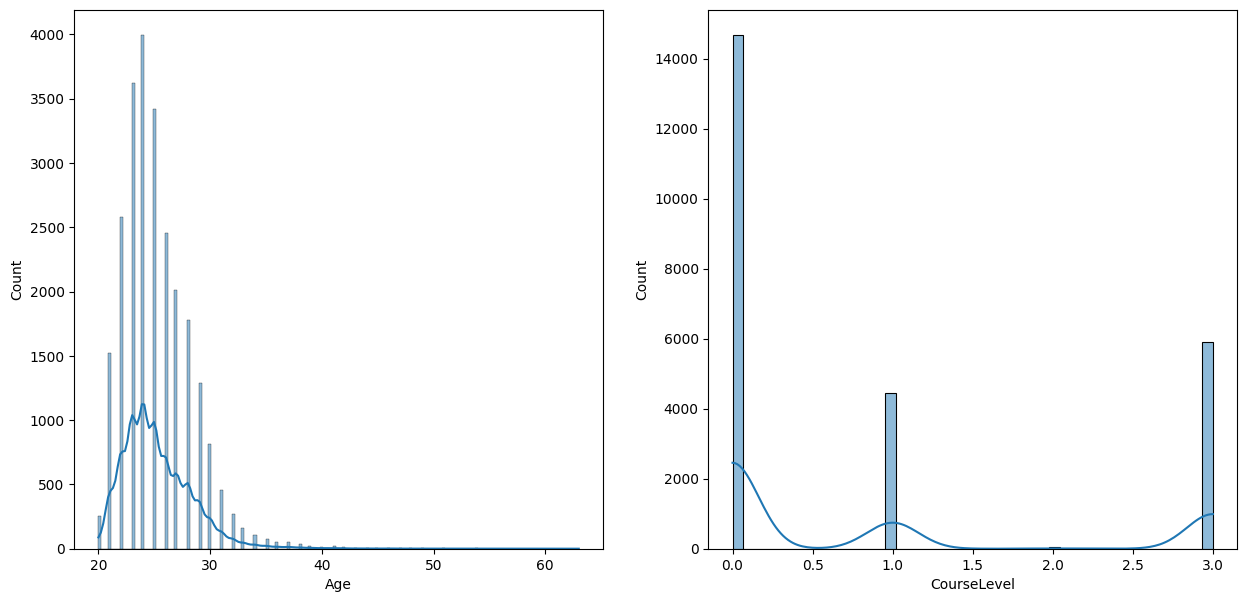

<Figure size 640x480 with 0 Axes>

In [ ]:
# Visualise data
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.histplot(data_df['Age'], kde = True)

plt.subplot(1, 2, 2)
sns.histplot(data_df['CourseLevel'], kde = True)

plt.show()

plt.tight_layout()


Target distribution (dropout):
dropout
0    0.850194
1    0.149806
Name: proportion, dtype: float64

Distribution count (dropout):
dropout
0    21305
1     3754
Name: count, dtype: int64


Text(0.5, 1.0, 'Target class distribution - dropout')

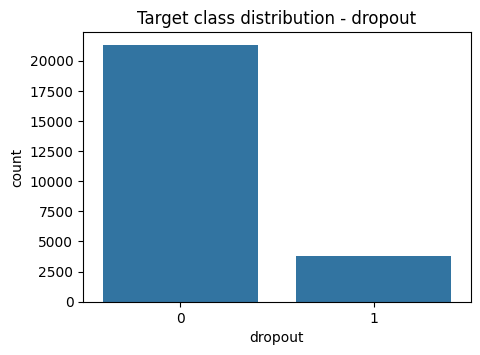

In [ ]:
#check for imbalance of the target variable - dropout

print("\nTarget distribution (dropout):")
print(data_df['dropout'].value_counts(normalize=True))

print("\nDistribution count (dropout):")
print(data_df['dropout'].value_counts())

plt.figure(figsize=(5, 3.5))
sns.countplot(x=data_df['dropout'])
plt.title("Target class distribution - dropout")


The data is imbalanced, with 85% not dropping out (21305 students) compared to 15% dropping out (3754 students)

## Train test split

In [ ]:
X = data_df.drop('dropout', axis=1).copy()
y = data_df['dropout'].copy()


In [ ]:
# ensure dropout column has gone
X

,CourseLevel,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,CentreName_ISC_Lancaster,CentreName_ISC_Leeds,...,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,Age
0,3,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,28
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,28
2,2,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,25
3,2,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,26
4,3,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25054,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,33
25055,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,31
25056,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
25057,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,24


In [ ]:
# should have one column of dropout
y

,dropout
0,0
1,0
2,0
3,0
4,0
...,...
25054,0
25055,0
25056,0
25057,1


In [ ]:
# Data has been correctly split into training and test set (use 80-20 split),
#use a 10% split of the training dataset as the validation dataset.

# stratify used to maintain proportions for y in both train/test as data is imbalanced

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

std = StandardScaler()

# Scale only for models that benefit from scaling (e.g. logistic regression) - however as these are binary mostly, might not make much difference here.
# data scaled due to features like age being varied. If have more time - could check if non-scaled data works better or not maybe
X_train_scaled = std.fit_transform(X_train)
X_val_scaled = std.transform(X_val)
X_test_scaled = std.transform(X_test)


In [ ]:
X_train_scaled

array([[ 1.71521258, -0.16900194, -0.12758894, ..., -0.29794217,
        -0.04471391,  1.47802345],
       [ 0.09220606, -0.16900194, -0.12758894, ...,  3.35635602,
        -0.04471391, -0.07767271],
       [-0.7192972 , -0.16900194, -0.12758894, ..., -0.29794217,
        -0.04471391, -0.07767271],
       ...,
       [ 0.09220606, -0.16900194, -0.12758894, ..., -0.29794217,
        -0.04471391, -0.69995118],
       [-0.7192972 , -0.16900194, -0.12758894, ..., -0.29794217,
        -0.04471391,  0.23346652],
       [ 1.71521258, -0.16900194, -0.12758894, ..., -0.29794217,
        -0.04471391,  0.85574498]])

Scaled data is calculated - as needed for neura netwroks later on. Note fit_transform isnt used on validation and test data as doing so would cause data leakage.

## XGBoost base

[0]	validation_0-logloss:0.34055
[1]	validation_0-logloss:0.31459
[2]	validation_0-logloss:0.30062
[3]	validation_0-logloss:0.29159
[4]	validation_0-logloss:0.28736
[5]	validation_0-logloss:0.28507
[6]	validation_0-logloss:0.28334
[7]	validation_0-logloss:0.28090
[8]	validation_0-logloss:0.27969
[9]	validation_0-logloss:0.27891
[10]	validation_0-logloss:0.27830
[11]	validation_0-logloss:0.27817
[12]	validation_0-logloss:0.27773
[13]	validation_0-logloss:0.27790
[14]	validation_0-logloss:0.27771
[15]	validation_0-logloss:0.27767
[16]	validation_0-logloss:0.27746
[17]	validation_0-logloss:0.27757
[18]	validation_0-logloss:0.27749
[19]	validation_0-logloss:0.27710
[20]	validation_0-logloss:0.27727
[21]	validation_0-logloss:0.27728
[22]	validation_0-logloss:0.27692
[23]	validation_0-logloss:0.27674
[24]	validation_0-logloss:0.27688
[25]	validation_0-logloss:0.27698
[26]	validation_0-logloss:0.27726
[27]	validation_0-logloss:0.27716
[28]	validation_0-logloss:0.27693
[29]	validation_0-loglos

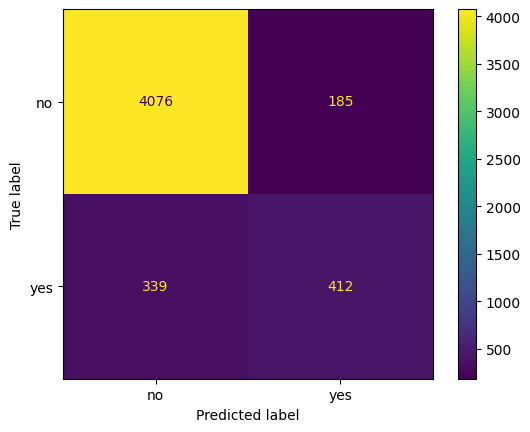

In [ ]:
# The XGBOOST model has been instantiated correctly and fitted on
# the training dataset

xg_model = xgb.XGBClassifier(random_state=seed)
# including validation - used AI to see how to include validation syntax into a xgboost model
history_xg = xg_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

# Model evaluation
predictions = xg_model.predict(X_test)
print("XGBoost Model Accuracy: ", accuracy_score(y_test, predictions))
print("XGBoost Model AUC: ", roc_auc_score(y_test, predictions))

print(classification_report(y_test, predictions))

print("\n Classification matrix of XGBoost base model\n")

cm = confusion_matrix(y_test, predictions)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

Can see the validation loss getting smaller which is good. Shows how well it looks at validation data.

Precision and recall seems high for test data for 0 (not drop out). However we are interested in the prediction of 1 - which is low for recall 0.55 (saying model correctly identified 55% of all actual dropouts), whichi s low. Accuracy and AUC ar ereasonable, but not great either. AUC is only 0.75.

You can see 4076 is predicted as 0 i.e will not drop out. Where as 412 will drop out - correct prediction.

However its 339 as false negative and 185 as false positive. The 339 - are missed opportunity to intervene.

## Hyperparameter tuning

In [ ]:
# The hyperparameter tuning of the learning rate, max depth,
# and number of estimators has been performed correctly.

from sklearn.model_selection import train_test_split, GridSearchCV

# Run a smaller tuning search for classroom runtime.
#X_tune, _, y_tune, _ = train_test_split(
#    X_train, y_train, train_size=min(12000, len(X_train)), stratify=y_train, random_state=seed
#)

X_tune = X_train
y_tune = y_train

models_param_grids = {
    'XGBoost Hyperparameter': {
        'model': xgb.XGBClassifier(random_state=seed, eval_metric='logloss', n_jobs=1),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.05, 0.1, 0.2, 0.3],
            'max_depth': [3, 5, 7],
        }
    }
}

tuning_rows = []
best_estimators = {}

for name, config in models_param_grids.items():
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['param_grid'],
        scoring='roc_auc',
        cv=2,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_tune, y_tune, eval_set=[(X_val, y_val)])

    best_model = grid.best_estimator_
    probs = best_model.predict_proba(X_test)[:, 1]
    preds = best_model.predict(X_test)

    tuning_rows.append({
        'model': name,
        'best_cv_auc': grid.best_score_,
        'test_auc': roc_auc_score(y_test, probs),
        'test_accuracy': accuracy_score(y_test, preds),
        'best_params': grid.best_params_,
    })
    best_estimators[name] = best_model

tuning_results = pd.DataFrame(tuning_rows).sort_values('test_auc', ascending=False)
display(tuning_results)

[0]	validation_0-logloss:0.36511
[1]	validation_0-logloss:0.33772
[2]	validation_0-logloss:0.32139
[3]	validation_0-logloss:0.31015
[4]	validation_0-logloss:0.30261
[5]	validation_0-logloss:0.29758
[6]	validation_0-logloss:0.29376
[7]	validation_0-logloss:0.29166
[8]	validation_0-logloss:0.28926
[9]	validation_0-logloss:0.28769
[10]	validation_0-logloss:0.28592
[11]	validation_0-logloss:0.28466
[12]	validation_0-logloss:0.28367
[13]	validation_0-logloss:0.28287
[14]	validation_0-logloss:0.28247
[15]	validation_0-logloss:0.28199
[16]	validation_0-logloss:0.28175
[17]	validation_0-logloss:0.28154
[18]	validation_0-logloss:0.28111
[19]	validation_0-logloss:0.28122
[20]	validation_0-logloss:0.28093
[21]	validation_0-logloss:0.28042
[22]	validation_0-logloss:0.28009
[23]	validation_0-logloss:0.27990
[24]	validation_0-logloss:0.27998
[25]	validation_0-logloss:0.28005
[26]	validation_0-logloss:0.27991
[27]	validation_0-logloss:0.27977
[28]	validation_0-logloss:0.27943
[29]	validation_0-loglos

,model,best_cv_auc,test_auc,test_accuracy,best_params
0,XGBoost Hyperparameter,0.879674,0.885335,0.893655,"{'learning_rate': 0.2, 'max_depth': 5, 'n_esti..."


              precision    recall  f1-score   support

           0       0.92      0.96      0.94      4261
           1       0.69      0.53      0.60       751

    accuracy                           0.89      5012
   macro avg       0.80      0.74      0.77      5012
weighted avg       0.89      0.89      0.89      5012


 Classification matrix of XGBoost base model



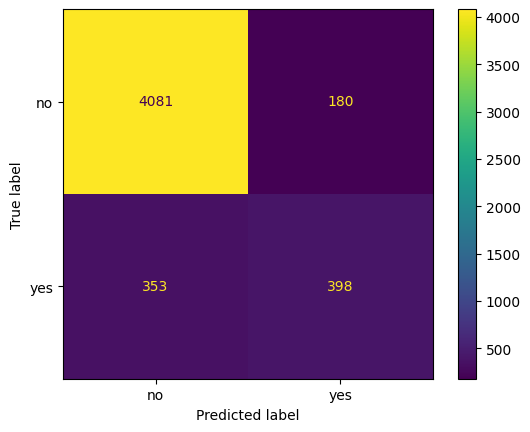

In [ ]:
# The metrics with and without hyperparameter tuning have been printed correctly and compared.
# Metrics include: Accuracy, confusion matrix, precision, recall and AUC on the test set

# note the base xgboost (without hyperpareter) was printed earlier

print(classification_report(y_test, preds))

print("\n Classification matrix of XGBoost base model\n")

cm = confusion_matrix(y_test, preds)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

Precision is same. Accuracy is similar, actually a bit lower. Recall is worse. However test AUC is better - gone to 0.88 compared to 0.75 previous.

This is very small difference on the true negatives i.e identifying not drop outs - as 4081 compared to base of 4076.
Drops out (true positives) went from to 412 to 398. Which is also similar
False negative went from 339 to 353 - increased. i.e. says drop out but it isnt a drop out.
False positives - gone from 185 to 180 - reduced i.e. says its drop out, but its not drop out

Given AUC increase - can see the hyperparameter tuned model is  better.


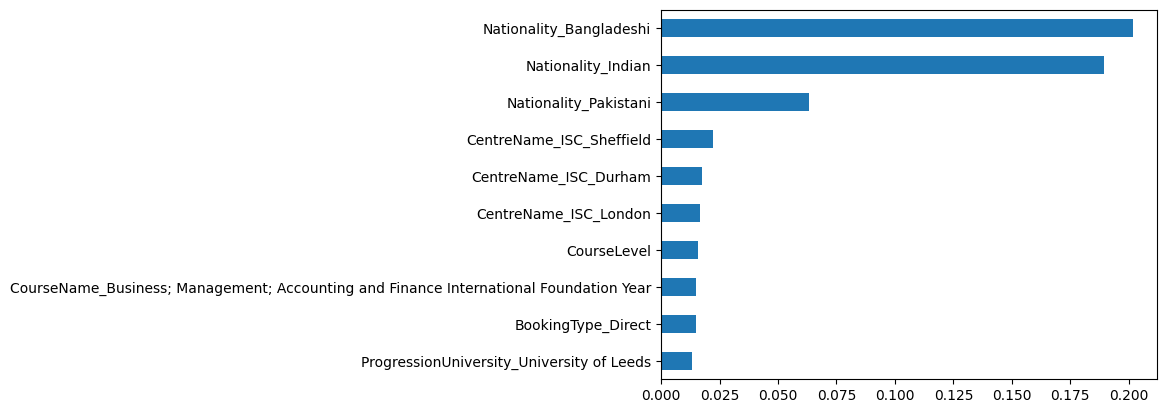

In [ ]:
# The plot of features importance has been correctly printed and commented on.

tuned_xg_model = best_estimators['XGBoost Hyperparameter']
feature_importance = pd.Series(tuned_xg_model.feature_importances_, index=X_train.columns).sort_values()

#feature_importance.plot.barh()
#plt.show()

feature_importance.iloc[-10:].plot.barh()
plt.show()


 Nationality seem to feature heavily at the top. When you look at the 2nd graph. Followed by CentreName, Coursename, booking type.... etc

 Remember - the features were one-hot encoded. Hence we see repeated features.

## Neural networks

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from datetime import datetime
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Input
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
from sklearn.datasets import make_classification
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:

# We have the features scaled for neural networks
# X_train_scaled = std.fit_transform(X_train) # (18,042, 389)
# X_val_scaled = std.transform(X_val) # (2005, 389)
# X_test_scaled = std.transform(X_test) # (5012, 389)

from sklearn.datasets import make_classification
import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense

# Build a simple neural network
model = Sequential([
    Dense(12, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile with AUC as the metric
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

# Train
history=model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled,y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Predict probabilities and compute AUC manually
y_pred_proba = model.predict(X_test_scaled).ravel()

auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC: {auc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.8172 - loss: 0.3371 - val_auc: 0.8315 - val_loss: 0.3074
Epoch 2/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.8764 - loss: 0.2743 - val_auc: 0.8465 - val_loss: 0.2960
Epoch 3/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.8878 - loss: 0.2646 - val_auc: 0.8506 - val_loss: 0.2938
Epoch 4/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.8940 - loss: 0.2592 - val_auc: 0.8564 - val_loss: 0.2936
Epoch 5/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8975 - loss: 0.2559 - val_auc: 0.8532 - val_loss: 0.2951
Epoch 6/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8990 - loss: 0.2533 - val_auc: 0.8562 - val_loss: 0.2912
Epoch 7/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9020 - loss: 0.2508 - val_auc: 0.8563 - val_loss: 0.2947
Epoch 8/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9039 - loss: 0.2494 - val_auc: 0.8582 - val_loss: 0.2935
Epoch 9/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

Test AUC is 0.8505

In [ ]:
print(history.history.keys())

dict_keys(['auc', 'loss', 'val_auc', 'val_loss'])


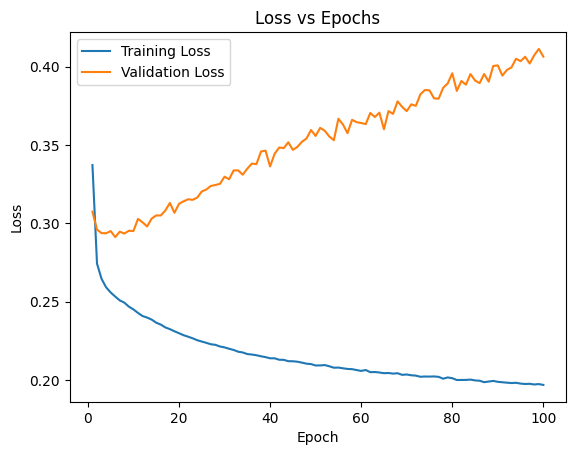

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history["loss"]) + 1)

plt.figure()
plt.plot(epochs, history.history["loss"])
plt.plot(epochs, history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss vs Epochs")
plt.show()

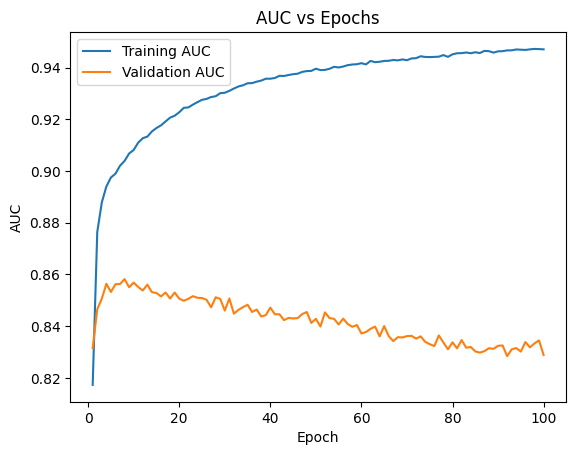

In [ ]:
plt.figure()
plt.plot(epochs, history.history["auc"])
plt.plot(epochs, history.history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend(["Training AUC", "Validation AUC"])
plt.title("AUC vs Epochs")
plt.show()

There is overfitting occuring here for the initial model. You can see the validation AUC reducing and the validation loss increasing, compared to the incresaed training AUC and reduced training loss.
The divergencfe between training and validation is seen.
This neural network created is a simple view - we will look to hyperparameter tuning to see if we can make this better.

To check on metrics further:

In [ ]:
y_pred_proba

array([1.1311254e-03, 1.7277545e-05, 2.1599843e-04, ..., 4.5423362e-02,
       1.8383975e-03, 4.2065836e-02], dtype=float32)

In [ ]:
y_pred_binary = (y_pred_proba>0.5).astype(int)
y_pred_binary

array([0, 0, 0, ..., 0, 0, 0])

Test accuracy score for neural network:  0.8830806065442937 

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      4261
           1       0.62      0.55      0.59       751

    accuracy                           0.88      5012
   macro avg       0.77      0.75      0.76      5012
weighted avg       0.88      0.88      0.88      5012


 Classification matrix of simple neural network base model



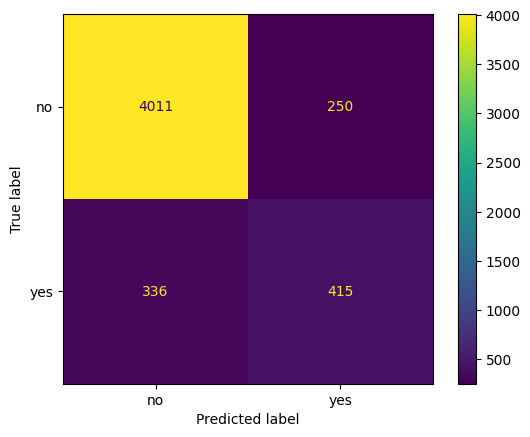

In [ ]:
acc = accuracy_score(y_test, y_pred_binary) #requires binary number
print(f"Test accuracy score for neural network: ", acc, "\n")

print(classification_report(y_test, y_pred_binary))

print("\n Classification matrix of simple neural network base model\n")

cm = confusion_matrix(y_test, y_pred_binary)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

Accurately verifies drop outs as 415 (greater than xgboost) and ones that dont as 4011 (less than xgboost).

AUC is 0.8505 (greater than xgboost base, but lower than xgboost tuned). Accuracy is 0.8831 (lower than xgboost)

Above is for neural network as a base, in which hyperparameter tunning hasn't been calculated for.

## Hyperparameter tuning - neural networks

In [ ]:
def create_model_reg(optimizer, HiddenNeurons, activation):
    model = Sequential()
    model.add(Dense(HiddenNeurons, activation="relu", kernel_regularizer=l2(0.01), input_shape=(X_train_scaled.shape[1],))),
    model.add(Dropout(0.2))
    model.add(Dense(int(HiddenNeurons/2), activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation=activation))
    # used AI to add in AUC metric on below line
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

# what happens to learning rate?
## could try two different neuron numbers for first and second layer

In [ ]:
tuning_rows = []
best_estimators = {}
best_auc_NN = 0
best_model_NN = None
best_model_history = None

for HiddenNeurons in [16, 32, 64]:
    for activation in ['sigmoid', 'tanh']:
      for optimiser in ['adam', 'rmsprop']:
        if optimiser == 'adam':
          model = create_model_reg(Adam(learning_rate=0.001), HiddenNeurons, activation)
        else:
          model = create_model_reg(RMSprop(learning_rate=0.001), HiddenNeurons, activation)
        history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_data=(X_val_scaled,y_val), verbose=0)
        # Predict probabilities and compute AUC manually  -
        y_pred_proba = model.predict(X_test_scaled).ravel()
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"Test AUC for ",HiddenNeurons, " neurons, and ", activation, " activation, ", optimiser, " optimiser is ", auc)
        tuning_rows.append({
            'Neurons': HiddenNeurons,
            'Activation': activation,
            'Optimiser used': optimiser,
            'Test AUC': auc,
        })
        if auc > best_auc_NN:
          best_auc_NN = auc
          best_model_NN = model
          best_model_history = history
          print(f"----------BEST MODEL IS ",HiddenNeurons, " neurons, and ", activation, " activation, ", optimiser, " optimiser is ", auc)


tuning_results = pd.DataFrame(tuning_rows).sort_values('Test AUC', ascending=False) # Changed 'Test AUC' to 'Test AUC '
display(tuning_results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test AUC for  16  neurons, and  sigmoid  activation,  adam  optimiser is  0.8729809053781377
----------BEST MODEL IS  16  neurons, and  sigmoid  activation,  adam  optimiser is  0.8729809053781377


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test AUC for  16  neurons, and  sigmoid  activation,  rmsprop  optimiser is  0.8670653007130289


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test AUC for  64  neurons, and  tanh  activation,  adam  optimiser is  0.8673045186407172


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test AUC for  64  neurons, and  tanh  activation,  rmsprop  optimiser is  0.8409649216830817


,Neurons,Activation,Optimiser used,Test AUC
8,64,sigmoid,adam,0.875381
6,32,tanh,adam,0.874246
2,16,tanh,adam,0.873043
0,16,sigmoid,adam,0.872981
4,32,sigmoid,adam,0.872114
10,64,tanh,adam,0.867305
1,16,sigmoid,rmsprop,0.867065
9,64,sigmoid,rmsprop,0.866771
5,32,sigmoid,rmsprop,0.866684
7,32,tanh,rmsprop,0.844841


## Best neural network

In [ ]:
#best_neural_model = create_model_reg(Adam(learning_rate=0.001), 32, 'tanh')
#best_history = best_neural_model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_data=(X_val_scaled,y_val), verbose=0)

best_neural_model = best_model_NN
best_history = best_model_history

# Predict probabilities and compute AUC manually  -
y_pred_proba = best_neural_model.predict(X_test_scaled).ravel()

auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC: {auc:.4f}")

### instead of running model again, you can save ealier best model and weights and draw graphs
### and calculate metrics


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test AUC: 0.8754


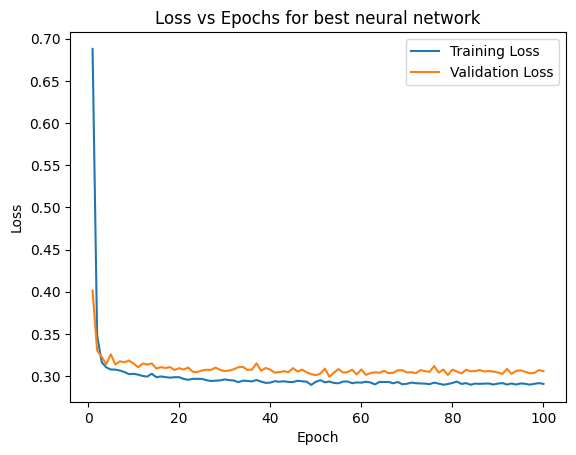

In [ ]:
epochs = range(1, len(best_history.history["loss"]) + 1)

plt.figure()
plt.plot(epochs, best_history.history["loss"])
plt.plot(epochs, best_history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss vs Epochs for best neural network")
plt.show()

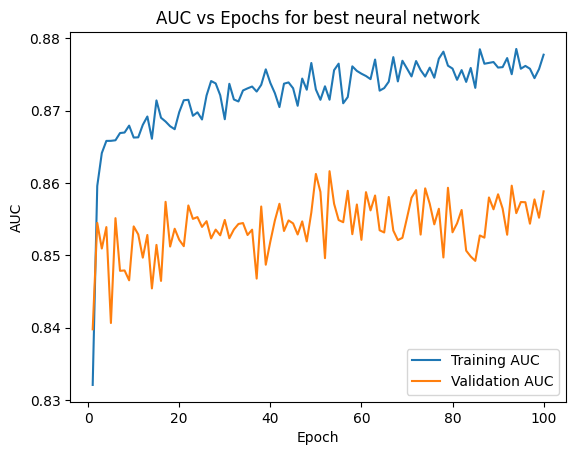

In [ ]:
plt.figure()
plt.plot(epochs, best_history.history["auc"])
plt.plot(epochs, best_history.history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend(["Training AUC", "Validation AUC"])
plt.title("AUC vs Epochs for best neural network")
plt.show()

The graphs aren't diverting as much as the earlier version. This shows the tunning and also higher AUC.

In [ ]:
y_pred_binary = (y_pred_proba>0.5).astype(int)
y_pred_binary

array([0, 0, 0, ..., 0, 0, 0])

Test accuracy score for neural network:  0.890462889066241 

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      4261
           1       0.67      0.54      0.60       751

    accuracy                           0.89      5012
   macro avg       0.79      0.75      0.77      5012
weighted avg       0.88      0.89      0.89      5012


 Classification matrix of simple neural network base model



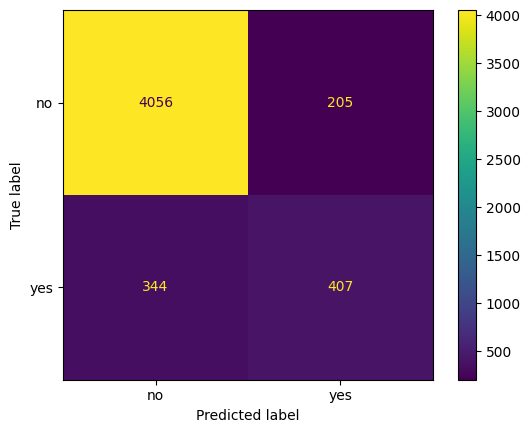

In [ ]:
acc = accuracy_score(y_test, y_pred_binary) #requires binary number
print(f"Test accuracy score for neural network: ", acc, "\n")

print(classification_report(y_test, y_pred_binary))

print("\n Classification matrix of simple neural network base model\n")

cm = confusion_matrix(y_test, y_pred_binary)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

4056 of true non-drop outs and 407 of true drop outs. Accuracy and prediction is high but lower than previous. This is the one with hyperparameter tunning done - calculated as above the metrics. Accuracy and AUC is better than base neural network, and AUC is also beter than xgboost, but not the tuned xgboost.

# Stage 2 data

In [ ]:
# File URL
file_url = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"
# Stage2_data.csv: This contains attendance metrics, including authorised absence and unauthorised absence counts.


# **Stage 2: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from datetime import datetime
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Input
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
from sklearn.datasets import make_classification
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping



In [ ]:
# import the data with the url provided
data2 = pd.read_csv('https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ')

seed = 42
np.random.seed(seed)


In [ ]:
# View the data shape
print(data2.shape)

# Display the first few rows
data2.head()



(25059, 18)


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN


Above shows same number of rows (25,059), but this time, two news features at the end (gone from 16 columns to 18):
AuthorisedAbsenceCount and UnauthorisedAbsenceCount
We can already see empty NaN values on both columns already.

In [ ]:
# Show metadata of data.
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-null  object 
 14  Progre

Both the numbers are floating numbers

In [ ]:
print(f'\n count of unique values in column \n')

# check for cardinality - counts number of unique values (excludes NaN values)
print(data2.apply(lambda col: col.nunique()))

print(f'\n unique values in column \n')

# look at the values
print(data2.apply(lambda col: col.unique()))


 count of unique values in column 

CentreName                     19
LearnerCode                 24877
BookingType                     2
LeadSource                      7
DiscountType                   11
DateofBirth                  4705
Gender                          2
Nationality                   151
HomeState                    2448
HomeCity                     5881
CourseLevel                     4
CourseName                    172
IsFirstIntake                   2
CompletedCourse                 2
ProgressionDegree            2616
ProgressionUniversity          40
AuthorisedAbsenceCount        190
UnauthorisedAbsenceCount      258
dtype: int64

 unique values in column 

CentreName                  [ISC_Aberdeen, ISC_Cardiff, ISC_Dublin, ISC_Du...
LearnerCode                 [2284932, 2399500, 2424946, 2426583, 2434674, ...
BookingType                                                   [Agent, Direct]
LeadSource                  [Standard Agent Booking, Sponsor, APD, Digital..

A number of unique values on last two columns (190 and 258).
As per guidelines, we need to remove columns with > 200 unique values for categorical features.

Date of birth wont be removed - as per stage 1, we will convert this to age, also its not categorical.

HomeState, HomeCity, ProgressionDegree - remain > 200 and also are categorical and will be dropped as stage 1.

UnauthorisedAbsenceCount - is more than 200 unique values, however its not categorical. So will keep this in.

In [ ]:
# Find missing values.
data2.isnull().sum()

,0
CentreName,0
LearnerCode,0
BookingType,0
LeadSource,0
DiscountType,17464
DateofBirth,0
Gender,0
Nationality,0
HomeState,16134
HomeCity,3448


There are 208 null/NaN values on both last two features. On a total of 25059 rows. This is 0.8% of the data. As this is < 2%. The data can be removed.

DiscountType show >50% missing data. So this will be removed. Note: the HomeState,HomeCity and ProgressionDegree were already planned to be removed as > 200 unique values.


In [ ]:
# see what the values in CourseLevel are
data2['CourseLevel'].unique()


array(['Pre-Masters', 'Foundation', 'International Year Two',
       'International Year One'], dtype=object)

Double checking the values in CourseLevel is the same, so the same process as stage 1 can be applied to it.

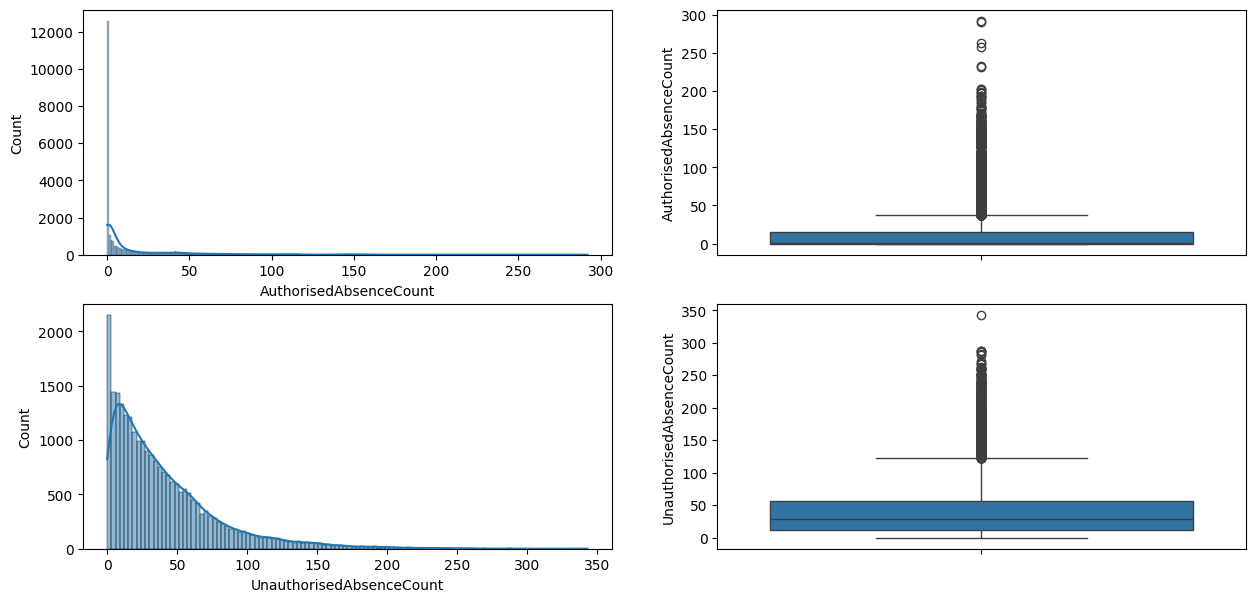

<Figure size 640x480 with 0 Axes>

In [ ]:
# Visualise data
plt.figure(figsize=(15, 7))

plt.subplot(2, 2, 1)
sns.histplot(data2['AuthorisedAbsenceCount'], kde = True)

plt.subplot(2, 2, 2)
sns.boxplot(data2['AuthorisedAbsenceCount'])

plt.subplot(2, 2, 3)
sns.histplot(data2['UnauthorisedAbsenceCount'], kde = True)

plt.subplot(2, 2, 4)
sns.boxplot(data2['UnauthorisedAbsenceCount'])

plt.show()

plt.tight_layout()

The values are very varied. The 0 values are contributing to the highest numbers i.e people who aren't absence from class

In [ ]:
# Redone stage 1 preprocessing onto a function as re-using for stage 2
# Note - the LearnerCode is being removed again as per instructions, and its an id which doesnt contribute to predictions
# Categorical columns removed as name
# > 50% data missing  - DiscountType is being removed
# Ordinal coding and one-hot performed as per Stage1
# convert DOB to age
# renamed target y columna and inverted 0 to 1, and 1 to 0, similar to stage 1

def preprocessing_stage2(data2):

    #dropping LearnerCode column
    data2.drop(['LearnerCode'], axis=1, inplace=True)

    #dropping categorical columns that have more than 200 unique values i.e. HomeState, HomeCity, ProgressionDegree
    data2.drop(['HomeState', 'HomeCity', 'ProgressionDegree'], axis=1, inplace=True)

    # Removing DiscountType column as it has > 50% data missing
    data2.drop(['DiscountType'], axis=1, inplace=True)

    #It looks like the order could be: foundation, int year 1, int year 2, pre masters
    order2 = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters']
    # create ordinal encoder
    ordinal_encoder2 = OrdinalEncoder(categories=[order2])
    #reshape data
    data2['CourseLevel'] = ordinal_encoder2.fit_transform(data2[['CourseLevel']]).astype(int)

    # perform one-hot encoding for categorical data
    # except courselevel, date of birth, IsFirstIntake and completed course (y)
    # the rest dont seem to have an order
    data_df2 = pd.get_dummies(data2,
                            columns=["CentreName", "BookingType", "LeadSource", "Gender", "Nationality", "CourseName", "IsFirstIntake", "ProgressionUniversity", "CompletedCourse"],
                            drop_first=True,
                            dtype=int)

    # Feature engineering
    # Convert the DOB to datetime
    data_df2['DOB'] = pd.to_datetime(data_df2['DateofBirth'],format='%d/%m/%Y')
    # Calculate age
    today2 = pd.Timestamp('now')
    data_df2['Age'] = (today2 - data_df2['DOB']).dt.days //365
    # drop extra features
    data_df2.drop(['DateofBirth', 'DOB'], axis=1, inplace=True)

    #rename target column
    data_df2.rename(columns={'CompletedCourse_Yes': 'dropout'}, inplace=True)
    # swap the 1 to 0 and 0  to 1, as we want to capture dropouts as 1, not completed course as 1
    data_df2['dropout'] = data_df2['dropout'].replace({0:1, 1:0})

    # imputation - removing the NaN values on the last two new columns as < 2% of data
    data_df2.dropna(how='all', subset=['AuthorisedAbsenceCount'], inplace = True)
    data_df2.dropna(how='all', subset=['UnauthorisedAbsenceCount'], inplace = True)

    data_df2.head()

    return data_df2


In [ ]:
data_df2 = preprocessing_stage2(data2)

In [ ]:
# Check for duplicate values
duplicate2 = data_df2[data_df2.duplicated()]

print("Duplicate Rows : ", duplicate2.count())

#view duplicates - note there are less duplicates compared to stage 1 - 13467.
# this is because the NaN values on new columns were removed, so some of the duplicates would have been removed
duplicate2

Duplicate Rows :  CourseLevel                                   1310
AuthorisedAbsenceCount                        1310
UnauthorisedAbsenceCount                      1310
CentreName_ISC_Cardiff                        1310
CentreName_ISC_Dublin                         1310
                                              ... 
ProgressionUniversity_University of Surrey    1310
ProgressionUniversity_University of Sussex    1310
ProgressionUniversity_VU Amsterdam            1310
dropout                                       1310
Age                                           1310
Length: 392, dtype: int64


,CourseLevel,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,...,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,dropout,Age
15,0,62.0,1.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,26
269,0,1.0,25.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,24
325,0,0.0,39.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25
745,0,10.0,6.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,21
1236,0,0.0,39.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24823,1,0.0,49.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,22
24830,1,0.0,7.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,24
24845,0,0.0,50.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,25
24859,0,0.0,50.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,25


In [ ]:
data_df2.describe()


,CourseLevel,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,...,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,dropout,Age
count,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,...,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000
mean,0.883385,15.120639,40.491892,0.027564,0.016056,0.103094,0.017545,0.070500,0.074806,0.037544,...,0.070500,0.063820,0.009698,0.236288,0.026478,0.042131,0.083940,0.002133,0.145226,25.223251
std,1.230008,28.918253,39.029384,0.163724,0.125692,0.304088,0.131291,0.255993,0.263083,0.190094,...,0.255993,0.244438,0.098001,0.424810,0.160555,0.200892,0.277304,0.046133,0.352335,3.167614
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
25%,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000
50%,0.000000,1.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000
75%,1.000000,15.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000
max,3.000000,292.000000,343.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,63.000000


The values are vastly different as seen before and require scaling for neural networks.
For the two new columns - data is from 0 to 292 and 0 to 343, with mean as 15 and 40. Which is seen on the graph earlier as well. The skew of data towards the left.

In [ ]:
data_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24851 entries, 1 to 25058
Columns: 392 entries, CourseLevel to Age
dtypes: float64(2), int64(390)
memory usage: 74.5 MB



Target distribution (dropout):
dropout
0    0.854774
1    0.145226
Name: proportion, dtype: float64

Distribution count (dropout):
dropout
0    21242
1     3609
Name: count, dtype: int64


Text(0.5, 1.0, 'Target class distribution - dropout')

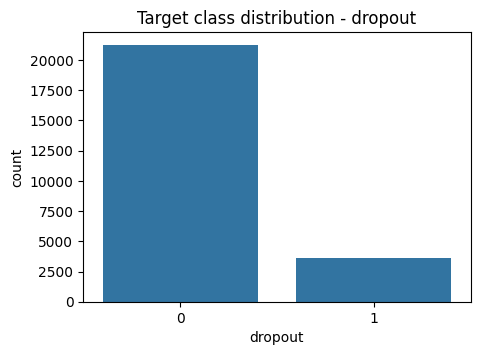

In [ ]:
#check for imbalance of the target variable - dropout

print("\nTarget distribution (dropout):")
print(data_df2['dropout'].value_counts(normalize=True))

print("\nDistribution count (dropout):")
print(data_df2['dropout'].value_counts())

plt.figure(figsize=(5, 3.5))
sns.countplot(x=data_df2['dropout'])
plt.title("Target class distribution - dropout")

# stage 1:
#0    0.850194
#1    0.149806
# Imbalance for stage 2 is similar. Changed with the removal of the NaN values row on the two new features

In [ ]:
data_df2.head()

# Can see the NAN values have gone from the two new features

,CourseLevel,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,...,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,dropout,Age
1,0,93.0,5.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
2,2,92.0,6.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25
3,2,67.0,15.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,26
5,2,67.0,3.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25
6,0,29.0,18.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,23


## Train test split (stage 2)

In [ ]:
# Start coding from here with Stage 2 dataset

X2 = data_df2.drop('dropout', axis=1).copy()
y2 = data_df2['dropout'].copy()



In [ ]:
# stratify used to maintain proportions for y in both train/test as data is imbalanced
# split data

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)

X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train2, y_train2, test_size=0.1, stratify=y_train2, random_state=42
)

std = StandardScaler()

# Scale only for models that benefit from scaling (e.g. logistic regression).
# Scaled data for Neural networks
X_train_scaled2 = std.fit_transform(X_train2)
X_val_scaled2 = std.transform(X_val2)
X_test_scaled2 = std.transform(X_test2)


## Intaniate XGBoost and Neural Network

[0]	validation_0-logloss:0.31847
[1]	validation_0-logloss:0.28645
[2]	validation_0-logloss:0.27030
[3]	validation_0-logloss:0.25998
[4]	validation_0-logloss:0.25264
[5]	validation_0-logloss:0.24725
[6]	validation_0-logloss:0.24320
[7]	validation_0-logloss:0.24068
[8]	validation_0-logloss:0.23774
[9]	validation_0-logloss:0.23663
[10]	validation_0-logloss:0.23584
[11]	validation_0-logloss:0.23494
[12]	validation_0-logloss:0.23466
[13]	validation_0-logloss:0.23283
[14]	validation_0-logloss:0.23151
[15]	validation_0-logloss:0.23155
[16]	validation_0-logloss:0.23129
[17]	validation_0-logloss:0.23103
[18]	validation_0-logloss:0.23125
[19]	validation_0-logloss:0.23112
[20]	validation_0-logloss:0.23125
[21]	validation_0-logloss:0.23088
[22]	validation_0-logloss:0.23053
[23]	validation_0-logloss:0.23026
[24]	validation_0-logloss:0.23057
[25]	validation_0-logloss:0.23053
[26]	validation_0-logloss:0.23083
[27]	validation_0-logloss:0.23084
[28]	validation_0-logloss:0.23077
[29]	validation_0-loglos

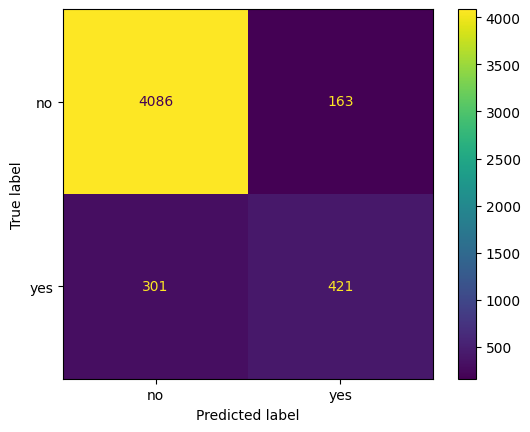

In [ ]:
# The XGBOOST model has been instantiated correctly and fitted on
# the new training dataset

xg_model2 = xgb.XGBClassifier(random_state=seed)
history_xg2 = xg_model2.fit(X_train2, y_train2, eval_set=[(X_val2, y_val2)])

# Model evaluation
predictions2 = xg_model2.predict(X_test2)
print("XGBoost Stage 2 Model Accuracy: ", accuracy_score(y_test2, predictions2))
print("XGBoost Stage 2 Model AUC: ", roc_auc_score(y_test2, predictions2))

print(classification_report(y_test2, predictions2))

print("\n Classification matrix of XGBoost Stage 2 base model\n")

cm2 = confusion_matrix(y_test2, predictions2)
cfmd2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["no","yes"])
cfmd2.plot()
plt.show()

Compared to stage 1 acc of 0.89545, stage 2 acc is better with 0.91.

AUC is also better with 0.77, in comparison to stage 1 auc of 0.75

A student identified as not dropping out is slightly higher 4086 (stage 2) compared to 4076 in stage 1. And a correct prediction of drop out is higher as well 421 in comparison to 412 in stage 1.



In [ ]:
# The Neural network model has been instantiated correctly and fitted on
# the new training dataset

# Build a simple neural network
modelNN2 = Sequential([
    Dense(12, activation="relu", input_shape=(X_train_scaled2.shape[1],)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile with AUC as the metric
modelNN2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

# Train
history=modelNN2.fit(
    X_train_scaled2,
    y_train2,
    validation_data=(X_val_scaled2,y_val2),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Predict probabilities and compute AUC manually
y_pred_proba2 = modelNN2.predict(X_test_scaled2).ravel()

auc = roc_auc_score(y_test2, y_pred_proba2)
print(f"Test AUC: {auc:.4f}")


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


560/560 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.8178 - loss: 0.3398 - val_auc: 0.8713 - val_loss: 0.2747
Epoch 2/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9008 - loss: 0.2508 - val_auc: 0.8810 - val_loss: 0.2660
Epoch 3/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.9134 - loss: 0.2372 - val_auc: 0.8896 - val_loss: 0.2592
Epoch 4/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9190 - loss: 0.2308 - val_auc: 0.8912 - val_loss: 0.2583
Epoch 5/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.9228 - loss: 0.2271 - val_auc: 0.8920 - val_loss: 0.2588
Epoch 6/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9257 - loss: 0.2227 - val_auc: 0.8939 - val_loss: 0.2585
Epoch 7/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9281 - loss: 0.2202 - val_auc: 0.8942 - val_loss: 0.2592
Epoch 8/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9296 - loss: 0.2176 - val_auc: 0.8939 - val_loss: 0.2592
Epoch 9/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 

Test AUC for neural network base here is 0.8606, which is higher in comparison to 0.7526 in stage 1

---



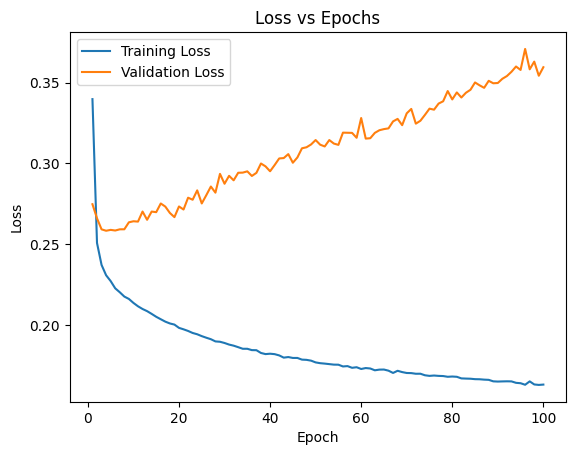

In [ ]:
epochs = range(1, len(history.history["loss"]) + 1)

plt.figure()
plt.plot(epochs, history.history["loss"])
plt.plot(epochs, history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss vs Epochs")
plt.show()

slightly less loss in comparison with stage 1, however the divergence is still seen

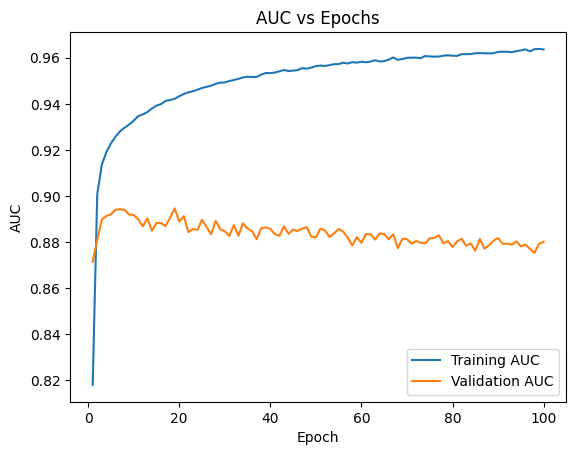

In [ ]:
plt.figure()
plt.plot(epochs, history.history["auc"])
plt.plot(epochs, history.history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend(["Training AUC", "Validation AUC"])
plt.title("AUC vs Epochs")
plt.show()

higher AUC reached compared to stage 1

In [ ]:
y_pred_binary2 = (y_pred_proba2>0.5).astype(int)
y_pred_binary2

array([0, 1, 0, ..., 0, 1, 0])

Test accuracy score for neural network:  0.8990142828404748 

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4249
           1       0.67      0.60      0.63       722

    accuracy                           0.90      4971
   macro avg       0.80      0.77      0.79      4971
weighted avg       0.89      0.90      0.90      4971


 Classification matrix of simple neural network base 2 model



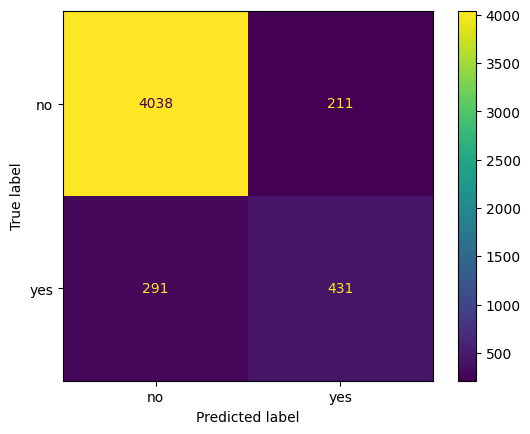

In [ ]:
acc = accuracy_score(y_test2, y_pred_binary2) #requires binary number
print(f"Test accuracy score for neural network: ", acc, "\n")

print(classification_report(y_test2, y_pred_binary2))

print("\n Classification matrix of simple neural network base 2 model\n")

cm = confusion_matrix(y_test2, y_pred_binary2)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

0.8990 accuracy is better than 0.8831 on stage 1.
Additionally a student not dropping out identified more as 4038 on stage 2, in comparison to 4011 in stage 1
Drop out identification is also more - 431 in stage 2, compared to 415 in stage 1. It has better AUC too - 0.8606 compared to 0.8505 in stage 1.

Results are different and slightly better for both xboost and nueral network - due to the extra features that ties better to the y variable/on what we are trying to predict.

## Hyperparameter tuning - xgboost stage 2

In [ ]:
X_tune2 = X_train2
y_tune2 = y_train2

models_param_grids2 = {
    'XGBoost Hyperparameter': {
        'model': xgb.XGBClassifier(random_state=seed, eval_metric='logloss', n_jobs=1),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.05, 0.1, 0.2, 0.3],
            'max_depth': [3, 5, 7],
        }
    }
}

tuning_rows2 = []
best_estimators2 = {}

for name, config in models_param_grids2.items():
    grid2 = GridSearchCV(
        estimator=config['model'],
        param_grid=config['param_grid'],
        scoring='roc_auc',
        cv=2,
        n_jobs=-1,
        verbose=0,
    )
    grid2.fit(X_tune2, y_tune2, eval_set=[(X_val2, y_val2)])

    best_model2 = grid2.best_estimator_
    probs2 = best_model2.predict_proba(X_test2)[:, 1]
    preds2 = best_model2.predict(X_test2)

    tuning_rows2.append({
        'model': name,
        'best_cv_auc': grid2.best_score_,
        'test_auc': roc_auc_score(y_test2, probs2),
        'test_accuracy': accuracy_score(y_test2, preds2),
        'best_params': grid2.best_params_,
    })
    best_estimators2[name] = best_model2

tuning_results2 = pd.DataFrame(tuning_rows2).sort_values('test_auc', ascending=False)
display(tuning_results2)

[0]	validation_0-logloss:0.39611
[1]	validation_0-logloss:0.38105
[2]	validation_0-logloss:0.36825
[3]	validation_0-logloss:0.35771
[4]	validation_0-logloss:0.34839
[5]	validation_0-logloss:0.33997
[6]	validation_0-logloss:0.33301
[7]	validation_0-logloss:0.32612
[8]	validation_0-logloss:0.31981
[9]	validation_0-logloss:0.31427
[10]	validation_0-logloss:0.30924
[11]	validation_0-logloss:0.30475
[12]	validation_0-logloss:0.30044
[13]	validation_0-logloss:0.29657
[14]	validation_0-logloss:0.29293
[15]	validation_0-logloss:0.28970
[16]	validation_0-logloss:0.28682
[17]	validation_0-logloss:0.28385
[18]	validation_0-logloss:0.28110
[19]	validation_0-logloss:0.27862
[20]	validation_0-logloss:0.27641
[21]	validation_0-logloss:0.27431
[22]	validation_0-logloss:0.27211
[23]	validation_0-logloss:0.27000
[24]	validation_0-logloss:0.26815
[25]	validation_0-logloss:0.26655
[26]	validation_0-logloss:0.26489
[27]	validation_0-logloss:0.26346
[28]	validation_0-logloss:0.26182
[29]	validation_0-loglos

,model,best_cv_auc,test_auc,test_accuracy,best_params
0,XGBoost Hyperparameter,0.911027,0.911149,0.909877,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est..."


Validation loss getting lower and lower in comparison to stage 1.

Best model found here is learning rate 0.05, max depth 5 and n estimators of 200.

Test auc is 0.911 is higher compared to 0.8853 in stage 1 tuning & higher than base model stage 2 acc of 0.7723.

Test accuracy is 0.9099 is higher compared to 0.88533 in stage 1 tuning & higher than base model stage 2 acc of 0.9067.


              precision    recall  f1-score   support

           0       0.93      0.97      0.95      4249
           1       0.74      0.58      0.65       722

    accuracy                           0.91      4971
   macro avg       0.84      0.77      0.80      4971
weighted avg       0.90      0.91      0.91      4971


 Classification matrix of XGBoost base stage 2 model



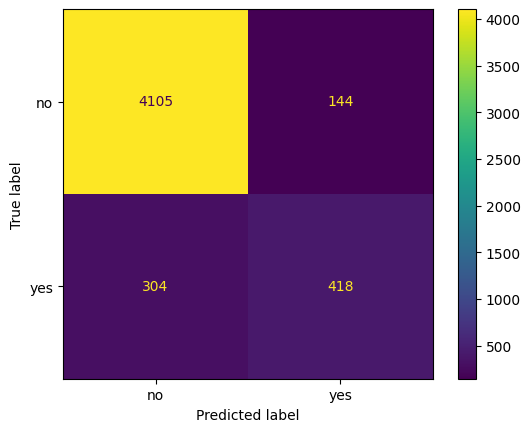

In [ ]:
print(classification_report(y_test2, preds2))

print("\n Classification matrix of XGBoost base stage 2 model\n")

cm = confusion_matrix(y_test2, preds2)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

The non drop outs are higher at 4105 compared to tuned version of 4081 in stage 1.
Similarly the drop out is also higher at 418 compared to 398 in stage 1. Which shows better predictions on both side.However its slightly lower than stage 2 base model of 421.

304 is lower in comparsion to 353 - sensitivity. Missed chance to help these students is also lower. But slightly higher compared to base of stage 2 of 301.

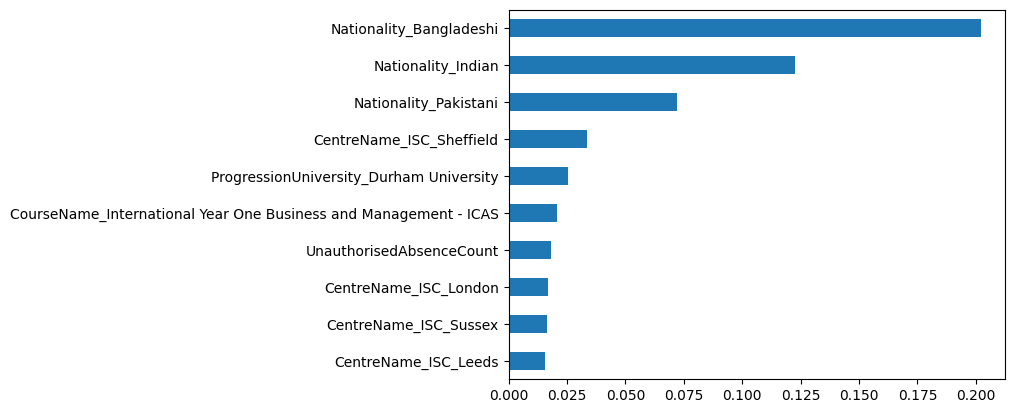

In [ ]:
# The plot of features importance has been correctly printed and commented on.

tuned_xg_model2 = best_estimators2['XGBoost Hyperparameter']
feature_importance2 = pd.Series(tuned_xg_model2.feature_importances_, index=X_train2.columns).sort_values()

feature_importance2.iloc[-10:].plot.barh()
plt.show()


feature importance is similar with nationality being top - however bangladeshi being higer than indian this time. Coursename has also come up - with the year 1 in particular for business and management. Followed by the center names in particular. Interestingly - one of the two new features come up here, in the top 10. So even though it plays a part, its one of the top indicator.

## Hyperparameter tuning - neural networks stage 2

In [ ]:
def create_model_reg2(optimizer, HiddenNeurons, activation):
    model = Sequential()
    model.add(Dense(HiddenNeurons, activation="relu", kernel_regularizer=l2(0.01), input_shape=(X_train_scaled2.shape[1],))),
    model.add(Dropout(0.2))
    model.add(Dense(int(HiddenNeurons/2), activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation=activation))
    # used AI to add in AUC metric on below line
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model


In [ ]:
tuning_rows2 = []
best_auc_NN2 = 0
best_model_NN2 = None
best_model_history = None

for HiddenNeurons in [16, 32, 64]:
    for activation in ['sigmoid', 'tanh']:
      for optimiser in ['adam', 'rmsprop']:
        if optimiser == 'adam':
          model2 = create_model_reg2(Adam(learning_rate=0.001), HiddenNeurons, activation)
        else:
          model2 = create_model_reg2(RMSprop(learning_rate=0.001), HiddenNeurons, activation)
        history2 = model2.fit(X_train_scaled2, y_train2, epochs=100, batch_size=32, validation_data=(X_val_scaled2,y_val2), verbose=0)
        # Predict probabilities and compute AUC manually  -
        y_pred_proba2 = model2.predict(X_test_scaled2).ravel()
        auc = roc_auc_score(y_test2, y_pred_proba2)
        print(f"Test AUC for stage 2 neural network tunning",HiddenNeurons, " neurons, and ", activation, " activation, ", optimiser, " optimiser is ", auc)
        tuning_rows2.append({
            'Neurons': HiddenNeurons,
            'Activation': activation,
            'Optimiser used': optimiser,
            'Test AUC': auc,
        })
        if auc > best_auc_NN2:
          best_auc_NN2 = auc
          best_model_NN2 = model2
          best_model_history = history2
          print(f"----------BEST MODEL stage 2 IS ",HiddenNeurons, " neurons, and ", activation, " activation, ", optimiser, " optimiser is ", auc)


tuning_results2 = pd.DataFrame(tuning_rows2).sort_values('Test AUC', ascending=False) # Changed 'Test AUC' to 'Test AUC '
display(tuning_results2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test AUC for stage 2 neural network tunning 16  neurons, and  sigmoid  activation,  adam  optimiser is  0.8804067634620236
----------BEST MODEL stage 2 IS  16  neurons, and  sigmoid  activation,  adam  optimiser is  0.8804067634620236


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test AUC for stage 2 neural network tunning 16  neurons, and  sigmoid  activation,  rmsprop  optimiser is  0.8825529422272406
----------BEST MODEL stage 2 IS  16  neurons, and  sigmoid  activation,  rmsprop  optimiser is  0.8825529422272406


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test AUC for stage 2 neural network tunning 64  neurons, and  tanh  activation,  adam  optimiser is  0.8854076142406653


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test AUC for stage 2 neural network tunning 64  neurons, and  tanh  activation,  rmsprop  optimiser is  0.8699205092415422


,Neurons,Activation,Optimiser used,Test AUC
8,64,sigmoid,adam,0.886116
6,32,tanh,adam,0.885791
10,64,tanh,adam,0.885408
2,16,tanh,adam,0.884404
9,64,sigmoid,rmsprop,0.884237
1,16,sigmoid,rmsprop,0.882553
4,32,sigmoid,adam,0.880932
5,32,sigmoid,rmsprop,0.880797
0,16,sigmoid,adam,0.880407
7,32,tanh,rmsprop,0.874111


In [ ]:
#best_neural_model2 = create_model_reg2(Adam(learning_rate=0.001), 64, 'sigmoid')
#best_history2 = best_neural_model2.fit(X_train_scaled2, y_train2, epochs=100, batch_size=32, validation_data=(X_val_scaled2,y_val2), verbose=0)
best_neural_model2 = best_model_NN2
best_history2 = best_model_history

# Predict probabilities and compute AUC manually  -
y_pred_proba2 = best_neural_model2.predict(X_test_scaled2).ravel()

auc = roc_auc_score(y_test2, y_pred_proba2)
print(f"Test AUC: {auc:.4f}")

### instead of running model again, you can save ealier best model and weights and draw graphs
### and calculate metrics


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test AUC: 0.8861


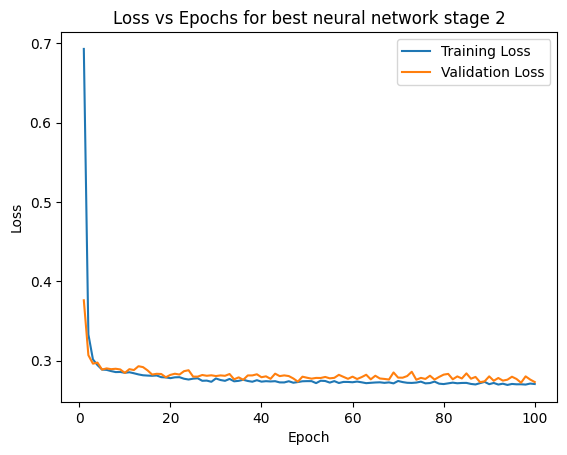

In [ ]:
epochs = range(1, len(best_history2.history["loss"]) + 1)

plt.figure()
plt.plot(epochs, best_history2.history["loss"])
plt.plot(epochs, best_history2.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss vs Epochs for best neural network stage 2")
plt.show()

loss is less here compared to stage 1

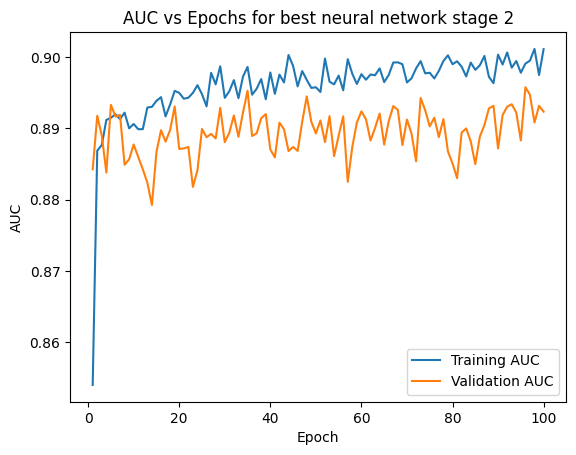

In [ ]:
plt.figure()
plt.plot(epochs, best_history2.history["auc"])
plt.plot(epochs, best_history2.history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend(["Training AUC", "Validation AUC"])
plt.title("AUC vs Epochs for best neural network stage 2")
plt.show()

slightly higher auc here and less split out compared to previous curves

In [ ]:
y_pred_binary2 = (y_pred_proba2>0.5).astype(int)
y_pred_binary2

array([0, 0, 0, ..., 0, 0, 0])

Test accuracy score for neural network stage 2:  0.8988131160732247 

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      4249
           1       0.68      0.56      0.62       722

    accuracy                           0.90      4971
   macro avg       0.81      0.76      0.78      4971
weighted avg       0.89      0.90      0.89      4971


 Classification matrix of simple neural network base model



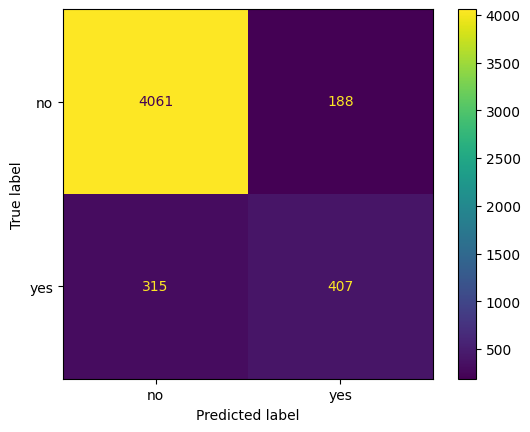

In [ ]:
acc = accuracy_score(y_test2, y_pred_binary2) #requires binary number
print(f"Test accuracy score for neural network stage 2: ", acc, "\n")

print(classification_report(y_test2, y_pred_binary2))

print("\n Classification matrix of simple neural network base model\n")

cm = confusion_matrix(y_test2, y_pred_binary2)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

Explain -
Stage 2 -
auc - is 0.8861 which is better than stage 1 0.8753, and slight better than base on stage 2
acc is 0.8988, better than 0.8904 of stage 1 and not better than base of stage 2 at 0.8990

Predict non drop outs is 4061, more than stage 1 - 4056
predict drop outs is 407, which is same as 407 stage 1
predict as non drop out but it is a drop out is 315, which is less than 344 stage 1 - missed opportunity.  


# Stage 3 data

In [ ]:
# File URL
file_url = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"

**Stage 3: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with rows that have missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.






In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from datetime import datetime
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Input
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
from sklearn.datasets import make_classification
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping



In [ ]:
# import the data with the url provided
data3 = pd.read_csv('https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-')

seed = 42
np.random.seed(seed)


In [ ]:
# View the data shape
print(data3.shape)

# Display the first few rows
data3.head()



(25059, 21)


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,...,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,...,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,...,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,...,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,...,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,...,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,MSc International Business Management,University of Aberdeen,NaN,NaN


Above shows same number of rows (25,059), but this time, 3 news features at the end (gone from 18 columns to ):
AssessedModules, PassedModules and FailedModules.
Cant see NaN visually on top few rows. But can see 0s.

In [ ]:
# Show metadata of data.
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-null  object 
 14  Assess

The 3 new columns are floating numbers

In [ ]:
print(f'\n count of unique values in column \n')

# check for cardinality - counts number of unique values (excludes NaN values)
print(data3.apply(lambda col: col.nunique()))

print(f'\n unique values in column \n')

# look at the values
print(data3.apply(lambda col: col.unique()))


 count of unique values in column 

CentreName                     19
LearnerCode                 24877
BookingType                     2
LeadSource                      7
DiscountType                   11
DateofBirth                  4705
Gender                          2
Nationality                   151
HomeState                    2448
HomeCity                     5881
CourseLevel                     4
CourseName                    172
IsFirstIntake                   2
CompletedCourse                 2
AssessedModules                12
PassedModules                  12
FailedModules                  11
ProgressionDegree            2616
ProgressionUniversity          40
AuthorisedAbsenceCount        190
UnauthorisedAbsenceCount      258
dtype: int64

 unique values in column 

CentreName                  [ISC_Aberdeen, ISC_Cardiff, ISC_Dublin, ISC_Du...
LearnerCode                 [2284932, 2399500, 2424946, 2426583, 2434674, ...
BookingType                                         

Nan values can be see on the new features. Also a smaller number of unique values.
Similar to stage 1 and 2, the remaining data preparing would need to be done.

In [ ]:
# Find missing values.
data3.isnull().sum()

,0
CentreName,0
LearnerCode,0
BookingType,0
LeadSource,0
DiscountType,17464
DateofBirth,0
Gender,0
Nationality,0
HomeState,16134
HomeCity,3448


There are 2231 nan values on all the 3 new features. On 25,059 rows - this is 8.9% of the total number of records. As it not < 2%, it can't be removed.

In [ ]:
#data3['AssessedModules'].value_counts()
#, 'PassedModules', 'FailedModules'].value_counts()
data3['FailedModules'].value_counts()


,count
FailedModules,
0.0,18598
1.0,1514
3.0,710
2.0,658
4.0,589
5.0,469
6.0,184
7.0,58
8.0,28


In [ ]:
# impute with zero values on new features
data3['FailedModules'] = data3['FailedModules'].fillna(0)
data3['AssessedModules'] = data3['AssessedModules'].fillna(0)
data3['PassedModules'] = data3['PassedModules'].fillna(0)


In [ ]:
# see what the values in CourseLevel are - are the same
data3['CourseLevel'].unique()

array(['Pre-Masters', 'Foundation', 'International Year Two',
       'International Year One'], dtype=object)

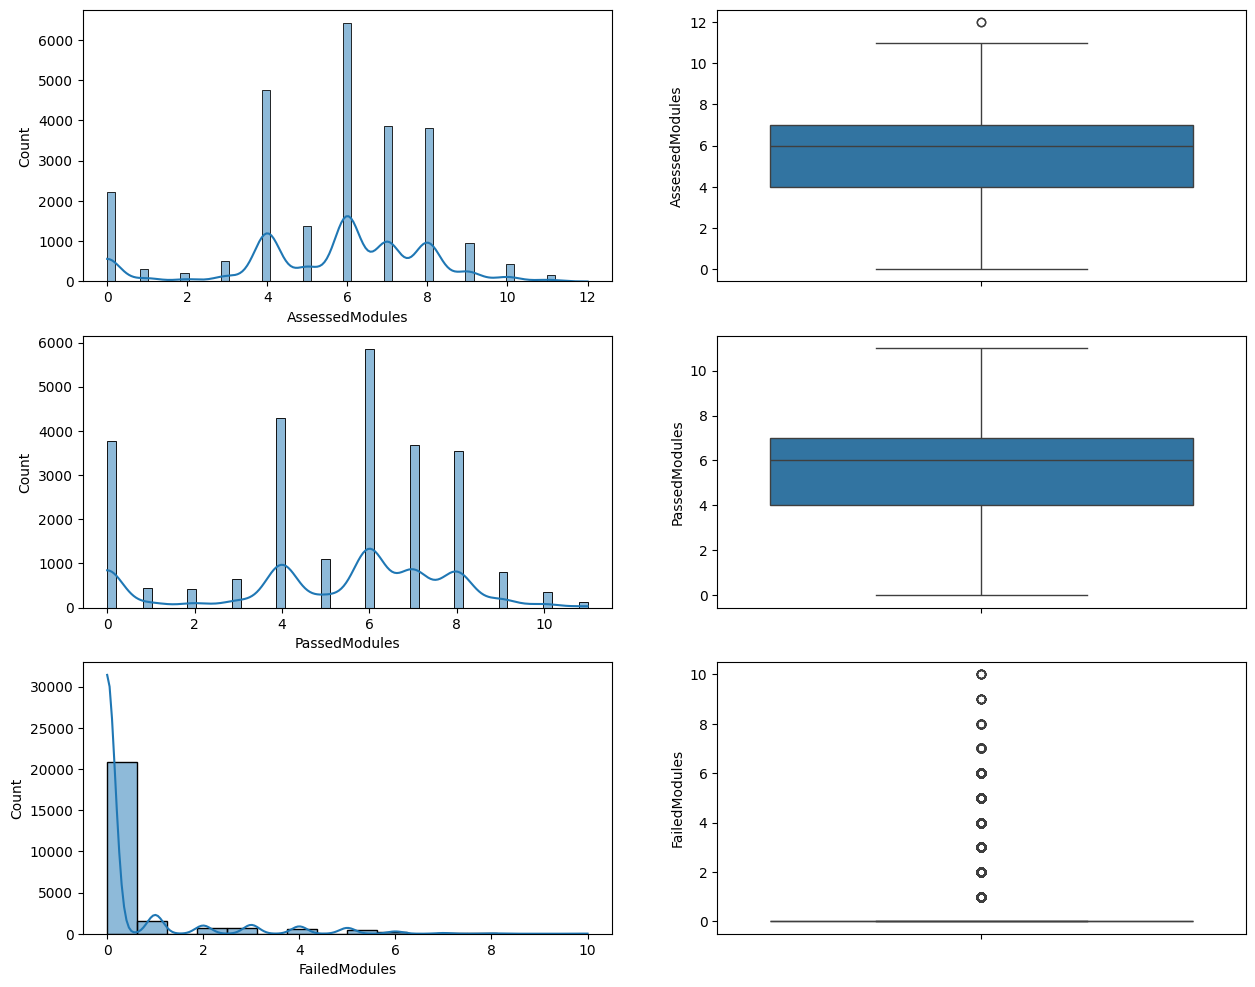

<Figure size 640x480 with 0 Axes>

In [ ]:
# Visualise data
plt.figure(figsize=(15, 12))

plt.subplot(3, 2, 1)
sns.histplot(data3['AssessedModules'], kde = True)

plt.subplot(3, 2, 2)
sns.boxplot(data3['AssessedModules'])

plt.subplot(3, 2, 3)
sns.histplot(data3['PassedModules'], kde = True)

plt.subplot(3, 2, 4)
sns.boxplot(data3['PassedModules'])

plt.subplot(3, 2, 5)
sns.histplot(data3['FailedModules'], kde = True)

plt.subplot(3, 2, 6)
sns.boxplot(data3['FailedModules'])

plt.show()

plt.tight_layout()

Graph shows distribution of the 3 new features. Last one is more skewed towards the 0s, as not many failed. The rest are in the middle ranges.

In [ ]:
# Redone stage 2 preprocessing
# Note - the LearnerCode is being removed again as per instructions, and its an id which doesnt contribute to predictions
# Categorical columns removed as name
# > 50% data missing  - DiscountType is being removed
# Ordinal coding and one-hot performed as per Stage1
# convert DOB to age
# renamed target y columna and inverted 0 to 1, and 1 to 0, similar to stage 1
# new features's nan values are converted to zero already earlier
# the stage 2 new features rows are dropped if nan

def preprocessing_stage3(data3):

    #dropping LearnerCode column
    data3.drop(['LearnerCode'], axis=1, inplace=True)

    #dropping categorical columns that have more than 200 unique values i.e. HomeState, HomeCity, ProgressionDegree
    data3.drop(['HomeState', 'HomeCity', 'ProgressionDegree'], axis=1, inplace=True)

    # Removing DiscountType column as it has > 50% data missing
    data3.drop(['DiscountType'], axis=1, inplace=True)

    #It looks like the order could be: foundation, int year 1, int year 2, pre masters
    order3 = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters']
    # create ordinal encoder
    ordinal_encoder3 = OrdinalEncoder(categories=[order3])
    #reshape data
    data3['CourseLevel'] = ordinal_encoder3.fit_transform(data3[['CourseLevel']]).astype(int)

    # perform one-hot encoding for categorical data
    # except courselevel, date of birth, IsFirstIntake and completed course (y)
    # the rest dont seem to have an order
    data_df3 = pd.get_dummies(data3,
                            columns=["CentreName", "BookingType", "LeadSource", "Gender", "Nationality", "CourseName", "IsFirstIntake", "ProgressionUniversity", "CompletedCourse"],
                            drop_first=True,
                            dtype=int)

    # Feature engineering
    # Convert the DOB to datetime
    data_df3['DOB'] = pd.to_datetime(data_df3['DateofBirth'],format='%d/%m/%Y')
    # Calculate age
    today3 = pd.Timestamp('now')
    data_df3['Age'] = (today3 - data_df3['DOB']).dt.days //365
    # drop extra features
    data_df3.drop(['DateofBirth', 'DOB'], axis=1, inplace=True)

    #rename target column
    data_df3.rename(columns={'CompletedCourse_Yes': 'dropout'}, inplace=True)
    # swap the 1 to 0 and 0  to 1, as we want to capture dropouts as 1, not completed course as 1
    data_df3['dropout'] = data_df3['dropout'].replace({0:1, 1:0})

    # imputation - removing the NaN values on the last two new columns as < 2% of data
    data_df3.dropna(how='all', subset=['AuthorisedAbsenceCount'], inplace = True)
    data_df3.dropna(how='all', subset=['UnauthorisedAbsenceCount'], inplace = True)

    data_df3.head()

    return data_df3


In [ ]:
data_df3 = preprocessing_stage3(data3)

In [ ]:
# Check for duplicate values
duplicate3 = data_df3[data_df3.duplicated()]

print("Duplicate Rows : ", duplicate3.count())

#reduced duplicates - note there are less duplicates compared to stage 2 - 1312.
# this is because of the new features
duplicate3

Duplicate Rows :  CourseLevel                                   1038
AssessedModules                               1038
PassedModules                                 1038
FailedModules                                 1038
AuthorisedAbsenceCount                        1038
                                              ... 
ProgressionUniversity_University of Surrey    1038
ProgressionUniversity_University of Sussex    1038
ProgressionUniversity_VU Amsterdam            1038
dropout                                       1038
Age                                           1038
Length: 395, dtype: int64


,CourseLevel,AssessedModules,PassedModules,FailedModules,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,...,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,dropout,Age
15,0,7.0,7.0,0.0,62.0,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,26
269,0,7.0,7.0,0.0,1.0,25.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,24
325,0,7.0,7.0,0.0,0.0,39.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25
745,0,7.0,7.0,0.0,10.0,6.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,21
1236,0,8.0,8.0,0.0,0.0,39.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24746,1,0.0,0.0,0.0,0.0,45.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,24
24823,1,1.0,0.0,1.0,0.0,49.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,22
24830,1,0.0,0.0,0.0,0.0,7.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,24
24859,0,2.0,0.0,2.0,0.0,50.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,25


In [ ]:
data_df3.describe()


,CourseLevel,AssessedModules,PassedModules,FailedModules,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,...,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,dropout,Age
count,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,...,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000,24851.000000
mean,0.883385,5.581908,5.116776,0.465132,15.120639,40.491892,0.027564,0.016056,0.103094,0.017545,...,0.070500,0.063820,0.009698,0.236288,0.026478,0.042131,0.083940,0.002133,0.145226,25.223251
std,1.230008,2.421783,2.740905,1.258029,28.918253,39.029384,0.163724,0.125692,0.304088,0.131291,...,0.255993,0.244438,0.098001,0.424810,0.160555,0.200892,0.277304,0.046133,0.352335,3.167614
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
25%,0.000000,4.000000,4.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000
50%,0.000000,6.000000,6.000000,0.000000,1.000000,29.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000
75%,1.000000,7.000000,7.000000,0.000000,15.000000,56.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000
max,3.000000,12.000000,11.000000,10.000000,292.000000,343.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,63.000000


The values require scaling for neural networks.
For the 3 new columns - data is similar range of 0 to 10/11/12. Which is seen on the graph earlier as well. Mean on pass/assessed is middle, but teh failed part is more towards 0 - i.e the mean.

In [ ]:
data_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24851 entries, 1 to 25058
Columns: 395 entries, CourseLevel to Age
dtypes: float64(5), int64(390)
memory usage: 75.1 MB



Target distribution (dropout):
dropout
0    0.854774
1    0.145226
Name: proportion, dtype: float64

Distribution count (dropout):
dropout
0    21242
1     3609
Name: count, dtype: int64


Text(0.5, 1.0, 'Target class distribution - dropout')

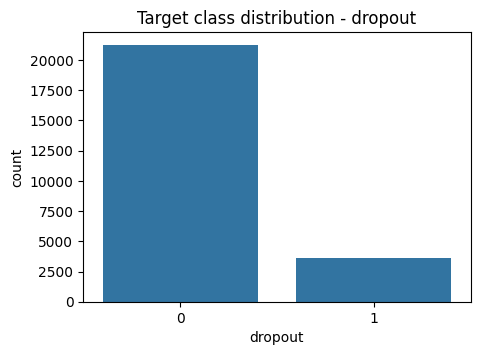

In [ ]:
#check for imbalance of the target variable - dropout

print("\nTarget distribution (dropout):")
print(data_df3['dropout'].value_counts(normalize=True))

print("\nDistribution count (dropout):")
print(data_df3['dropout'].value_counts())

plt.figure(figsize=(5, 3.5))
sns.countplot(x=data_df3['dropout'])
plt.title("Target class distribution - dropout")

# stage 2:
#0    0.854774
#1    0.145226
# Imbalance for stage 3 is same to 2 (as rows weren't deleted)

In [ ]:
data_df3.head()

,CourseLevel,AssessedModules,PassedModules,FailedModules,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,...,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam,dropout,Age
1,0,7.0,7.0,0.0,93.0,5.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
2,2,8.0,8.0,0.0,92.0,6.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25
3,2,8.0,8.0,0.0,67.0,15.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,26
5,2,8.0,8.0,0.0,67.0,3.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25
6,0,0.0,0.0,0.0,29.0,18.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,23


## Train test split (stage 3)

In [ ]:
# Start coding from here with Stage 3 dataset

X3 = data_df3.drop('dropout', axis=1).copy()
y3 = data_df3['dropout'].copy()



In [ ]:
# stratify used to maintain proportions for y in both train/test as data is imbalanced
# split data

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, stratify=y3, random_state=42
)

X_train3, X_val3, y_train3, y_val3 = train_test_split(
    X_train3, y_train3, test_size=0.1, stratify=y_train3, random_state=42
)

std = StandardScaler()

# Scale only for models that benefit from scaling (e.g. logistic regression).
# Scaled data for Neural networks
X_train_scaled3 = std.fit_transform(X_train3)
X_val_scaled3 = std.transform(X_val3)
X_test_scaled3 = std.transform(X_test3)


## Instantiate XGBoost and Neural Network Stage 3

[0]	validation_0-logloss:0.20088
[1]	validation_0-logloss:0.15001
[2]	validation_0-logloss:0.11701
[3]	validation_0-logloss:0.09429
[4]	validation_0-logloss:0.07808
[5]	validation_0-logloss:0.06715
[6]	validation_0-logloss:0.05821
[7]	validation_0-logloss:0.05195
[8]	validation_0-logloss:0.04843
[9]	validation_0-logloss:0.04511
[10]	validation_0-logloss:0.04203
[11]	validation_0-logloss:0.03995
[12]	validation_0-logloss:0.03928
[13]	validation_0-logloss:0.03822
[14]	validation_0-logloss:0.03728
[15]	validation_0-logloss:0.03649
[16]	validation_0-logloss:0.03600
[17]	validation_0-logloss:0.03529
[18]	validation_0-logloss:0.03485
[19]	validation_0-logloss:0.03457
[20]	validation_0-logloss:0.03489
[21]	validation_0-logloss:0.03465
[22]	validation_0-logloss:0.03431
[23]	validation_0-logloss:0.03427
[24]	validation_0-logloss:0.03432
[25]	validation_0-logloss:0.03393
[26]	validation_0-logloss:0.03342
[27]	validation_0-logloss:0.03340
[28]	validation_0-logloss:0.03365
[29]	validation_0-loglos

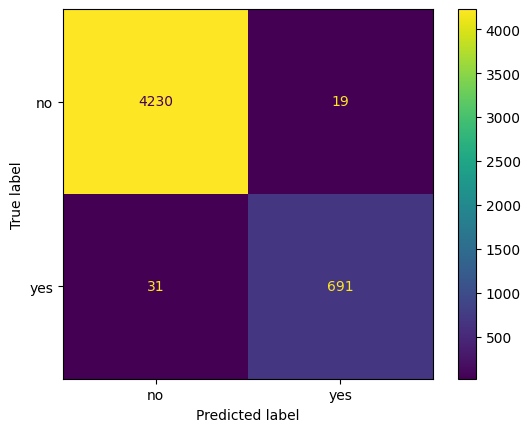

In [ ]:
# The XGBOOST model has been instantiated correctly and fitted on
# the new training dataset

xg_model3 = xgb.XGBClassifier(random_state=seed)
history_xg3 = xg_model3.fit(X_train3, y_train3, eval_set=[(X_val3, y_val3)])

# Model evaluation
predictions3 = xg_model3.predict(X_test3)
print("XGBoost Stage 3 Model Accuracy: ", accuracy_score(y_test3, predictions3))
print("XGBoost Stage 3 Model AUC: ", roc_auc_score(y_test3, predictions3))

print(classification_report(y_test3, predictions3))

print("\n Classification matrix of XGBoost Stage 3 base model\n")

cm3 = confusion_matrix(y_test3, predictions3)
cfmd3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=["no","yes"])
cfmd3.plot()
plt.show()

Compared to stage 2  acc of 0.91, stage 3 acc is significantly better with 0.99.

AUC is also better with 0.976, in comparison to stage 2 auc of 0.772

A student identified as not dropping out is higher 4230 (stage 3) compared to 4086 in stage 2. And a correct prediction of drop out is higher as well 691 in comparison to 421 in stage 2. False negative has dropped significantly to 31 (compared to 301 in stage 2). Recall has gone up signficantly to 0.96 in comparison to 0.58 in stage 2.



In [ ]:
# The Neural network model has been instantiated correctly and fitted on
# the new training dataset

# Build a simple neural network
modelNN3 = Sequential([
    Dense(12, activation="relu", input_shape=(X_train_scaled3.shape[1],)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile with AUC as the metric
modelNN3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

# Train
history=modelNN3.fit(
    X_train_scaled3,
    y_train3,
    validation_data=(X_val_scaled3,y_val3),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Predict probabilities and compute AUC manually
y_pred_proba3 = modelNN3.predict(X_test_scaled3).ravel()

auc = roc_auc_score(y_test3, y_pred_proba3)
print(f"Test AUC: {auc:.4f}")


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc: 0.9492 - loss: 0.1967 - val_auc: 0.9851 - val_loss: 0.0984
Epoch 2/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9935 - loss: 0.0607 - val_auc: 0.9929 - val_loss: 0.0566
Epoch 3/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9972 - loss: 0.0387 - val_auc: 0.9942 - val_loss: 0.0488
Epoch 4/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9980 - loss: 0.0309 - val_auc: 0.9947 - val_loss: 0.0452
Epoch 5/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9983 - loss: 0.0272 - val_auc: 0.9950 - val_loss: 0.0433
Epoch 6/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9984 - loss: 0.0249 - val_auc: 0.9947 - val_loss: 0.0489
Epoch 7/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9990 - loss: 0.0225 - val_auc: 0.9949 - val_loss: 0.0466
Epoch 8/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9990 - loss: 0.0213 - val_auc: 0.9946 - val_loss: 0.0475
Epoch 9/100
560/560 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 

Test AUC for neural network base here is 0.9964, which is higher in comparison to 0.8606 in stage 2


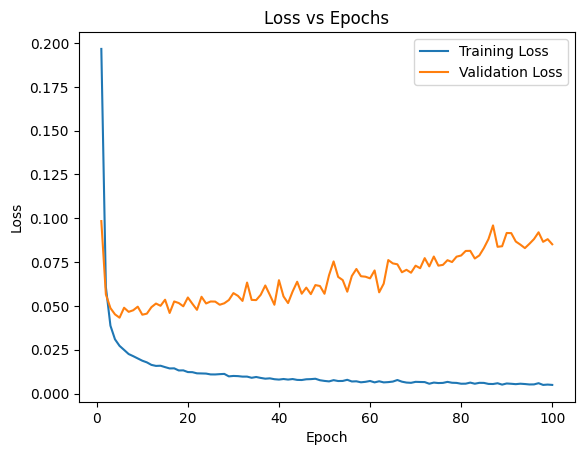

In [ ]:
epochs = range(1, len(history.history["loss"]) + 1)

plt.figure()
plt.plot(epochs, history.history["loss"])
plt.plot(epochs, history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss vs Epochs")
plt.show()

Less loss compared to stage 2. However diversion still there between the two lines

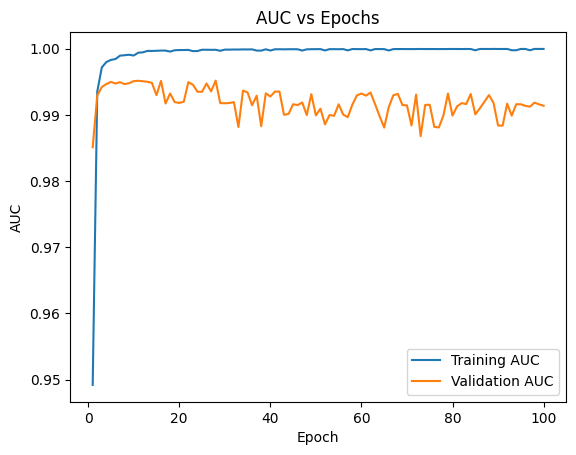

In [ ]:
plt.figure()
plt.plot(epochs, history.history["auc"])
plt.plot(epochs, history.history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend(["Training AUC", "Validation AUC"])
plt.title("AUC vs Epochs")
plt.show()

AUC is higher and earlier epochs are closer together but diverges again

In [ ]:
y_pred_binary3 = (y_pred_proba3>0.5).astype(int)
y_pred_binary3

array([0, 0, 0, ..., 0, 1, 0])

Test accuracy score for neural network stage 3:  0.987929993964997 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4249
           1       0.96      0.96      0.96       722

    accuracy                           0.99      4971
   macro avg       0.98      0.97      0.98      4971
weighted avg       0.99      0.99      0.99      4971


 Classification matrix of simple neural network base 3 model



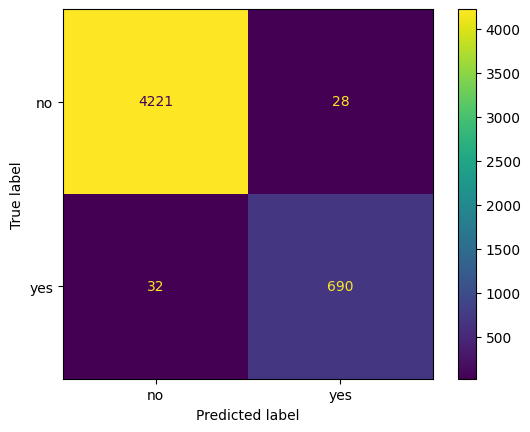

In [ ]:
acc = accuracy_score(y_test3, y_pred_binary3) #requires binary number
print(f"Test accuracy score for neural network stage 3: ", acc, "\n")

print(classification_report(y_test3, y_pred_binary3))

print("\n Classification matrix of simple neural network base 3 model\n")

cm = confusion_matrix(y_test3, y_pred_binary3)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

0.987 accuracy is better than 0.8990 on stage 2.
Additionally a student not dropping out identified more as 4221 on stage 3, in comparison to 4039 in stage 2
Drop out identification is more - 690 in stage 3, compared to 431 in stage 1.
No tuning done. Much better identifications.

Results are different and slightly better for both xboost and nueral network - due to the extra features that ties better to the y variable/on what we are trying to predict.

Notice teh significant difference on false negative 'missed oppportunity' being 32, in comparison to 291 in stage 2. So much improvement.

## Hyperparameter tuning - xgboost stage 3

In [ ]:
X_tune3 = X_train3
y_tune3 = y_train3

models_param_grids3 = {
    'XGBoost Hyperparameter': {
        'model': xgb.XGBClassifier(random_state=seed, eval_metric='logloss', n_jobs=1),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.05, 0.1, 0.2, 0.3],
            'max_depth': [3, 5, 7],
        }
    }
}

tuning_rows3 = []
best_estimators3 = {}

for name, config in models_param_grids2.items():
    grid3 = GridSearchCV(
        estimator=config['model'],
        param_grid=config['param_grid'],
        scoring='roc_auc',
        cv=2,
        n_jobs=-1,
        verbose=0,
    )
    grid3.fit(X_tune3, y_tune3, eval_set=[(X_val3, y_val3)])

    best_model3 = grid3.best_estimator_
    probs3 = best_model3.predict_proba(X_test3)[:, 1]
    preds3 = best_model3.predict(X_test3)

    tuning_rows3.append({
        'model': name,
        'best_cv_auc': grid3.best_score_,
        'test_auc': roc_auc_score(y_test3, probs3),
        'test_accuracy': accuracy_score(y_test3, preds3),
        'best_params': grid3.best_params_,
    })
    best_estimators3[name] = best_model3

tuning_results3 = pd.DataFrame(tuning_rows3).sort_values('test_auc', ascending=False)
display(tuning_results3)

[0]	validation_0-logloss:0.26486
[1]	validation_0-logloss:0.21053
[2]	validation_0-logloss:0.17379
[3]	validation_0-logloss:0.14709
[4]	validation_0-logloss:0.12627
[5]	validation_0-logloss:0.11040
[6]	validation_0-logloss:0.09814
[7]	validation_0-logloss:0.08842
[8]	validation_0-logloss:0.08037
[9]	validation_0-logloss:0.07391
[10]	validation_0-logloss:0.06860
[11]	validation_0-logloss:0.06441
[12]	validation_0-logloss:0.06094
[13]	validation_0-logloss:0.05822
[14]	validation_0-logloss:0.05571
[15]	validation_0-logloss:0.05398
[16]	validation_0-logloss:0.05238
[17]	validation_0-logloss:0.05032
[18]	validation_0-logloss:0.04880
[19]	validation_0-logloss:0.04777
[20]	validation_0-logloss:0.04670
[21]	validation_0-logloss:0.04620
[22]	validation_0-logloss:0.04570
[23]	validation_0-logloss:0.04522
[24]	validation_0-logloss:0.04485
[25]	validation_0-logloss:0.04403
[26]	validation_0-logloss:0.04372
[27]	validation_0-logloss:0.04335
[28]	validation_0-logloss:0.04267
[29]	validation_0-loglos

,model,best_cv_auc,test_auc,test_accuracy,best_params
0,XGBoost Hyperparameter,0.998937,0.99934,0.990545,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti..."


Validation loss getting lower and lower in comparison to stage 2.

Best model found here is learning rate 0.2, max depth 3 and n estimators of 200.

Test auc is 0.99934 is higher compared to 0.9111 in stage 2 tuning & higher than base model stage 3 acc of 0.9763.

Test accuracy is 0.9905 is higher compared to 0.9098 in stage 2 tuning & higher than base model stage 3 auc of 0.9899.

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4249
           1       0.98      0.96      0.97       722

    accuracy                           0.99      4971
   macro avg       0.99      0.98      0.98      4971
weighted avg       0.99      0.99      0.99      4971


 Classification matrix of XGBoost base stage 3 model



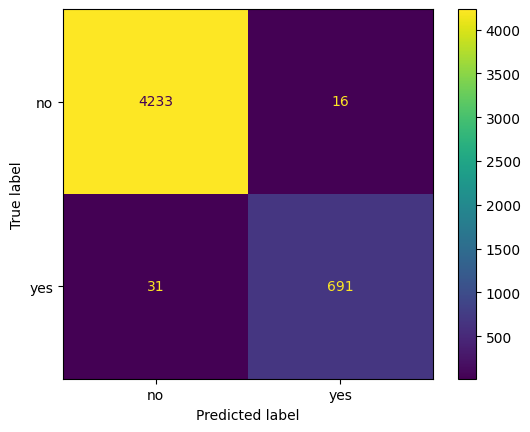

In [ ]:
print(classification_report(y_test3, preds3))

print("\n Classification matrix of XGBoost base stage 3 model\n")

cm = confusion_matrix(y_test3, preds3)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

The non drop outs are higher at 4233 compared to tuned version of 4105 in stage 2.
Similarly the drop out is also higher at 691 compared to 418 in stage 2. Which shows better predictions on both side.

31 is much lower in comparsion to 304 - sensitivity. Missed chance to help these students is also lower. This is good.
Only slightly better than stage 3 base in predictions quandrant. However its higher on accuracy and auc when compared to base stage 3.

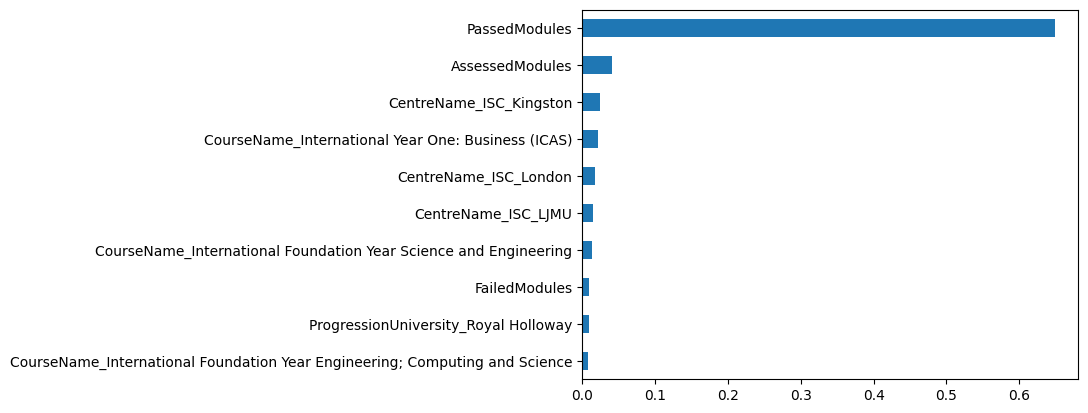

In [ ]:
# The plot of features importance has been correctly printed and commented on.

tuned_xg_model3 = best_estimators3['XGBoost Hyperparameter']
feature_importance3 = pd.Series(tuned_xg_model3.feature_importances_, index=X_train3.columns).sort_values()

feature_importance3.iloc[-10:].plot.barh()
plt.show()


Shows the new features of passed and assessed modules are top of the feature importance now. Including failed being part of top 10.

## Hyperparameter tuning - neural networks stage 3

In [ ]:
def create_model_reg3(optimizer, HiddenNeurons, activation):
    model = Sequential()
    model.add(Dense(HiddenNeurons, activation="relu", kernel_regularizer=l2(0.01), input_shape=(X_train_scaled3.shape[1],))),
    model.add(Dropout(0.2))
    model.add(Dense(int(HiddenNeurons/2), activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation=activation))
    # used AI to add in AUC metric on below line
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model


In [ ]:
tuning_rows3 = []
best_auc_NN3 = 0
best_model_NN3 = None
best_model_history3 = None

for HiddenNeurons in [16, 32, 64]:
    for activation in ['sigmoid', 'tanh']:
      for optimiser in ['adam', 'rmsprop']:
        if optimiser == 'adam':
          model3 = create_model_reg3(Adam(learning_rate=0.001), HiddenNeurons, activation)
        else:
          model3 = create_model_reg3(RMSprop(learning_rate=0.001), HiddenNeurons, activation)
        history3 = model3.fit(X_train_scaled3, y_train3, epochs=100, batch_size=32, validation_data=(X_val_scaled3,y_val3), verbose=0)
        # Predict probabilities and compute AUC manually  -
        y_pred_proba3 = model3.predict(X_test_scaled3).ravel()
        auc = roc_auc_score(y_test3, y_pred_proba3)
        print(f"Test AUC for stage 3 neural network tunning",HiddenNeurons, " neurons, and ", activation, " activation, ", optimiser, " optimiser is ", auc)
        tuning_rows3.append({
            'Neurons': HiddenNeurons,
            'Activation': activation,
            'Optimiser used': optimiser,
            'Test AUC': auc,
        })
        if auc > best_auc_NN3:
          best_auc_NN3 = auc
          best_model_NN3 = model3
          best_model_history3 = history3
          print(f"----------BEST MODEL stage 3 IS ",HiddenNeurons, " neurons, and ", activation, " activation, ", optimiser, " optimiser is ", auc)


tuning_results3 = pd.DataFrame(tuning_rows3).sort_values('Test AUC', ascending=False)
display(tuning_results3)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test AUC for stage 3 neural network tunning 16  neurons, and  sigmoid  activation,  adam  optimiser is  0.9968469035243098
----------BEST MODEL stage 3 IS  16  neurons, and  sigmoid  activation,  adam  optimiser is  0.9968469035243098


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test AUC for stage 3 neural network tunning 16  neurons, and  sigmoid  activation,  rmsprop  optimiser is  0.9984109019622671
----------BEST MODEL stage 3 IS  16  neurons, and  sigmoid  activation,  rmsprop  optimiser is  0.9984109019622671


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test AUC for stage 3 neural network tunning 64  neurons, and  tanh  activation,  adam  optimiser is  0.9984343717179013


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test AUC for stage 3 neural network tunning 64  neurons, and  tanh  activation,  rmsprop  optimiser is  0.9979551975403697


,Neurons,Activation,Optimiser used,Test AUC
5,32,sigmoid,rmsprop,0.998836
9,64,sigmoid,rmsprop,0.998520
10,64,tanh,adam,0.998434
1,16,sigmoid,rmsprop,0.998411
8,64,sigmoid,adam,0.998307
4,32,sigmoid,adam,0.998075
2,16,tanh,adam,0.998028
11,64,tanh,rmsprop,0.997955
6,32,tanh,adam,0.997808
3,16,tanh,rmsprop,0.997477


In [ ]:
#best_neural_model2 = create_model_reg2(Adam(learning_rate=0.001), 64, 'sigmoid')
#best_history2 = best_neural_model2.fit(X_train_scaled2, y_train2, epochs=100, batch_size=32, validation_data=(X_val_scaled2,y_val2), verbose=0)
best_neural_model3 = best_model_NN3
best_history3 = best_model_history3

# Predict probabilities and compute AUC manually  -
y_pred_proba3 = best_neural_model3.predict(X_test_scaled3).ravel()

auc = roc_auc_score(y_test3, y_pred_proba3)
print(f"Test AUC: {auc:.4f}")

### instead of running model again, you can save ealier best model and weights and draw graphs
### and calculate metrics


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test AUC: 0.9988


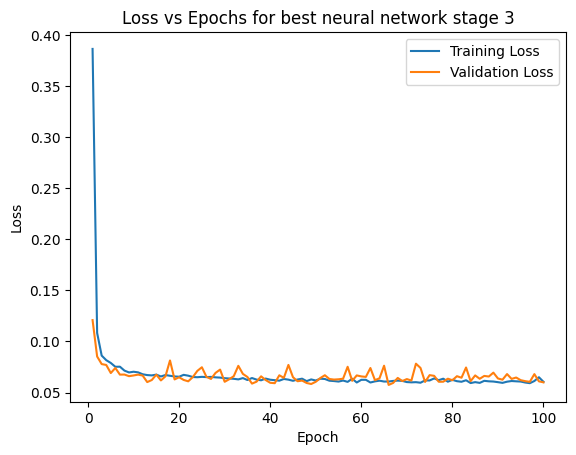

In [ ]:
epochs = range(1, len(best_history3.history["loss"]) + 1)

plt.figure()
plt.plot(epochs, best_history3.history["loss"])
plt.plot(epochs, best_history3.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss vs Epochs for best neural network stage 3")
plt.show()

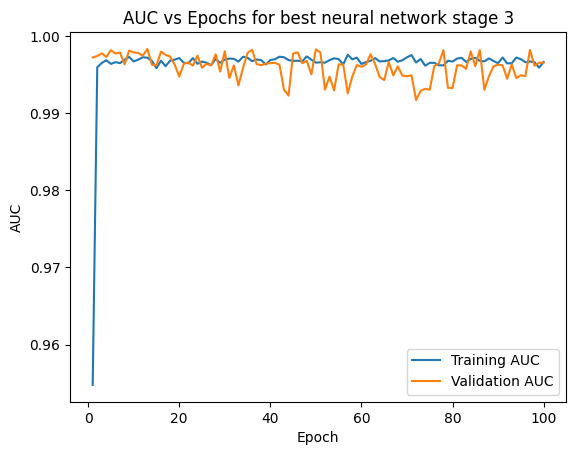

In [ ]:
plt.figure()
plt.plot(epochs, best_history3.history["auc"])
plt.plot(epochs, best_history3.history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend(["Training AUC", "Validation AUC"])
plt.title("AUC vs Epochs for best neural network stage 3")
plt.show()

In [ ]:
y_pred_binary3 = (y_pred_proba3>0.5).astype(int)
y_pred_binary3

array([0, 0, 0, ..., 0, 1, 0])

Test accuracy score for neural network stage 3:  0.9863206598269966 

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4249
           1       0.98      0.93      0.95       722

    accuracy                           0.99      4971
   macro avg       0.98      0.96      0.97      4971
weighted avg       0.99      0.99      0.99      4971


 Classification matrix of simple neural network base 3 model



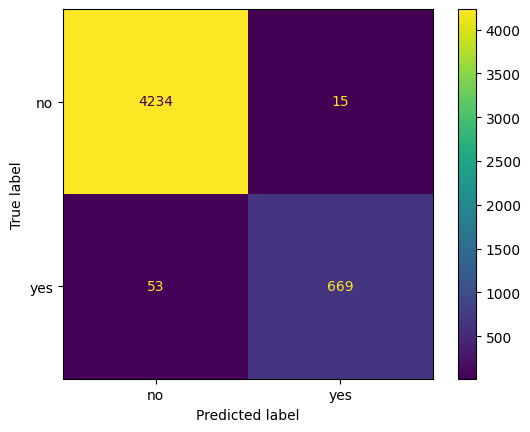

In [ ]:
acc = accuracy_score(y_test3, y_pred_binary3) #requires binary number
print(f"Test accuracy score for neural network stage 3: ", acc, "\n")

print(classification_report(y_test3, y_pred_binary3))

print("\n Classification matrix of simple neural network base 3 model\n")

cm = confusion_matrix(y_test3, y_pred_binary3)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no","yes"])
cfmd.plot()
plt.show()

Explain -


Stage 3 -
auc - is 0.9988 which is better than stage 2 0.8861
acc is 0.9863, better than 0.8988 of stage 2

Predict non drop outs is 4234, more than stage 2 - 4061
predict drop outs is 669, which is better than 407 stage 2

predict as non drop out but it is a drop out is 53, which is less than 315 stage 2 - missed opportunity.  


# Declaration
By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the **Cambridge plagiarism regulations**.
